In [5]:
import os
import json
import pandas as pd

RAW_DATA = "data/raw"

print("Dataset folders:")
print(os.listdir(RAW_DATA))

Dataset folders:
['archive.zip', 'comp', 'matches', 'players', 'teams']


In [6]:
for root, dirs, files in os.walk(RAW_DATA):
    for file in files:
        if file.endswith(".json"):
            print(os.path.join(root, file))

data/raw\comp\comp_data.json
data/raw\matches\match_data_4653703.json
data/raw\matches\match_data_4653704.json
data/raw\matches\match_data_4653705.json
data/raw\matches\match_data_4653706.json
data/raw\matches\match_data_4653707.json
data/raw\matches\match_data_4653708.json
data/raw\matches\match_data_4653709.json
data/raw\matches\match_data_4653710.json
data/raw\matches\match_data_4653711.json
data/raw\matches\match_data_4653712.json
data/raw\matches\match_data_4653713.json
data/raw\matches\match_data_4653714.json
data/raw\matches\match_data_4653715.json
data/raw\matches\match_data_4653716.json
data/raw\matches\match_data_4653717.json
data/raw\matches\match_data_4653718.json
data/raw\matches\match_data_4653842.json
data/raw\matches\match_data_4653843.json
data/raw\matches\match_data_4653844.json
data/raw\matches\match_data_4653845.json
data/raw\matches\match_data_4653846.json
data/raw\matches\match_data_4653847.json
data/raw\matches\match_data_4653848.json
data/raw\matches\match_data_

In [7]:
for folder in ["comp", "matches", "players", "teams"]:
    path = os.path.join(RAW_DATA, folder)
    files = [
        f for f in os.listdir(path)
        if os.path.isfile(os.path.join(path, f))
    ]
    print(f"{folder}: {len(files)} files")

comp: 4 files
matches: 104 files
players: 0 files
teams: 48 files


In [8]:
import os

comp_path = "data/raw/comp"

print(os.listdir(comp_path))

['comp_data.json', 'fixtures_lookup.csv', 'players_lookup.csv', 'teams_lookup.csv']


In [9]:
import pandas as pd

player_lookup_path = "data/raw/comp/players_lookup.csv"

players = pd.read_csv(player_lookup_path)

players.head()

,player_id,player_name,country,country_id,birth_date_utc,primary_position,club_id,club_name,height_cm,preferred_foot,transfer_value_eur
0,1057426,Armin Gigovic,Bosnia and Herzegovina,10106,2002-04-06,defensive midfielder,10192.0,Young Boys,187.0,right,1950982.0
1,1174844,Jovo Lukic,Bosnia and Herzegovina,10106,1998-11-28,striker,89022.0,Universitatea Cluj,190.0,left,959713.0
2,1179875,Ivan Basic,Bosnia and Herzegovina,10106,2002-04-30,central midfielder,166865.0,FC Astana,178.0,left,724785.0
3,1250485,Tarik Muharemovic,Bosnia and Herzegovina,10106,2003-02-28,center back,8463.0,Leeds United,187.0,left,17870981.0
4,1284492,Samed Bazdar,Bosnia and Herzegovina,10106,2004-01-31,striker,8394.0,Real Zaragoza,186.0,right,1251348.0


In [10]:
players.columns.tolist()

['player_id',
 'player_name',
 'country',
 'country_id',
 'birth_date_utc',
 'primary_position',
 'club_id',
 'club_name',
 'height_cm',
 'preferred_foot',
 'transfer_value_eur']

In [12]:
print("Total rows:", len(players))
print("Unique player IDs:", players["player_id"].nunique())
print("Unique player names:", players["player_name"].nunique())

Total rows: 1243
Unique player IDs: 1243
Unique player names: 1242


In [13]:
print("Duplicate player IDs:", players["player_id"].duplicated().sum())

Duplicate player IDs: 0


In [14]:
players.isnull().sum()

player_id              0
player_name            0
country                0
country_id             0
birth_date_utc         0
primary_position       0
club_id               21
club_name             21
height_cm              2
preferred_foot         0
transfer_value_eur    57
dtype: int64

In [15]:
players[players["club_name"].isna()]

,player_id,player_name,country,country_id,birth_date_utc,primary_position,club_id,club_name,height_cm,preferred_foot,transfer_value_eur
10,15403,Edin Dzeko,Bosnia and Herzegovina,10106,1986-03-17,striker,NaN,NaN,193.0,both,990541.0
64,292462,Mohamed Salah,Egypt,10255,1992-06-15,right winger,NaN,NaN,175.0,left,35103349.0
93,467479,Riechedly Bazoer,Curacao,287981,1996-10-12,center back,NaN,NaN,184.0,right,1152541.0
313,1181438,Martin Expérience,Haiti,5934,1999-03-09,left wing-back,NaN,NaN,178.0,left,217557.0
367,1178629,Jayden Adams,South Africa,6316,2001-05-05,defensive midfielder,NaN,NaN,175.0,right,316800.0
534,195927,Enner Valencia,Ecuador,6707,1989-11-04,striker,NaN,NaN,177.0,right,1001139.0
686,1806615,Benjamin Asare,Ghana,6714,1992-07-13,keeper,NaN,NaN,188.0,right,NaN
694,776591,Abdul Mumin,Ghana,6714,1998-06-06,defender,NaN,NaN,188.0,right,2110965.0
713,664444,Takehiro Tomiyasu,Japan,6715,1998-11-05,center back,NaN,NaN,187.0,right,4456133.0
738,185644,Mathew Ryan,Australia,6716,1992-04-08,keeper,NaN,NaN,184.0,right,1514941.0


In [16]:
players[players["height_cm"].isna()]

,player_id,player_name,country,country_id,birth_date_utc,primary_position,club_id,club_name,height_cm,preferred_foot,transfer_value_eur
1168,1135782,Taha Abdi Ali,Sweden,8520,1998-07-01,right midfielder,8619.0,PAOK Thessaloniki,NaN,right,625013.0
1172,1272349,Elliot Stroud,Sweden,8520,2002-06-22,left midfielder,8127.0,Mjällby,NaN,left,2088915.0


In [17]:
players[players["transfer_value_eur"].isna()][
    ["player_id", "player_name", "country", "club_name"]
]

,player_id,player_name,country,club_name
12,1726288,Mladen Jurkas,Bosnia and Herzegovina,Borac Banja Luka
55,1228546,Mostafa Ahmed Shobeir,Egypt,Al Ahly SC
60,1426403,Mostafa Ziko,Egypt,Pyramids FC
63,1708842,Hamza Abdelkarim,Egypt,Barca Atletic
158,1036253,Noor Al Rawabdeh,Jordan,Selangor
159,1059129,Mohammad Abuzraiq,Jordan,Raja Casablanca
160,1179369,Saed Al-Rosan,Jordan,Ethad All Ramtha
163,1213678,Amer Jamous,Jordan,Al Zawraa
165,1312681,Abdallah Nasib,Jordan,Al-Hussein SC
167,1554109,Husam Abu Dahab,Jordan,Al-Faisaly


In [23]:
import pandas as pd
import numpy as np

In [24]:
players_clean = players.copy()

# Remove whitespace from text columns
text_columns = [
    "player_name",
    "country",
    "primary_position",
    "club_name",
    "preferred_foot"
]

for col in text_columns:
    players_clean[col] = players_clean[col].str.strip()

# Convert date
players_clean["birth_date_utc"] = pd.to_datetime(
    players_clean["birth_date_utc"],
    errors="coerce"
)

# Convert numeric columns
players_clean["height_cm"] = pd.to_numeric(
    players_clean["height_cm"],
    errors="coerce"
)

players_clean["transfer_value_eur"] = pd.to_numeric(
    players_clean["transfer_value_eur"],
    errors="coerce"
)

# Keep missing club names as Unknown
players_clean["club_name"] = players_clean["club_name"].fillna("Unknown")

# Remove duplicate player IDs
players_clean = players_clean.drop_duplicates(
    subset="player_id"
)

In [25]:
print("Original rows:", len(players))
print("Cleaned rows:", len(players_clean))

print("\nMissing values:")
print(players_clean.isnull().sum())

Original rows: 1243
Cleaned rows: 1243

Missing values:
player_id              0
player_name            0
country                0
country_id             0
birth_date_utc         0
primary_position       0
club_id               21
club_name              0
height_cm              2
preferred_foot         0
transfer_value_eur    57
dtype: int64


In [26]:
players_clean.head()

,player_id,player_name,country,country_id,birth_date_utc,primary_position,club_id,club_name,height_cm,preferred_foot,transfer_value_eur
0,1057426,Armin Gigovic,Bosnia and Herzegovina,10106,2002-04-06,defensive midfielder,10192.0,Young Boys,187.0,right,1950982.0
1,1174844,Jovo Lukic,Bosnia and Herzegovina,10106,1998-11-28,striker,89022.0,Universitatea Cluj,190.0,left,959713.0
2,1179875,Ivan Basic,Bosnia and Herzegovina,10106,2002-04-30,central midfielder,166865.0,FC Astana,178.0,left,724785.0
3,1250485,Tarik Muharemovic,Bosnia and Herzegovina,10106,2003-02-28,center back,8463.0,Leeds United,187.0,left,17870981.0
4,1284492,Samed Bazdar,Bosnia and Herzegovina,10106,2004-01-31,striker,8394.0,Real Zaragoza,186.0,right,1251348.0


In [27]:
import os

os.makedirs("data/processed", exist_ok=True)

players_clean.to_csv(
    "data/processed/players_clean.csv",
    index=False
)

In [28]:
#Load teams_lookup.csv

team_lookup_path = "data/raw/comp/teams_lookup.csv"

teams = pd.read_csv(team_lookup_path)

print("Rows:", len(teams))
print("Columns:")
print(teams.columns.tolist())

teams.head()

Rows: 48
Columns:
['team_id', 'team', 'group_id', 'group', 'fifa_rank', 'rank_last_updated', 'current_head_coach', 'head_coach_id']


,team_id,team,group_id,group,fifa_rank,rank_last_updated,current_head_coach,head_coach_id
0,6710,Mexico,894790,Group A,14,2026-06-11,Javier Aguirre,78642.0
1,6316,South Africa,894790,Group A,60,2026-06-11,Hugo Broos,179919.0
2,7804,South Korea,894790,Group A,25,2026-06-11,NaN,NaN
3,8496,Czechia,894790,Group A,40,2026-06-11,NaN,NaN
4,6717,Switzerland,894791,Group B,19,2026-06-11,Murat Yakin,34053.0


In [29]:
teams.isnull().sum()

team_id               0
team                  0
group_id              0
group                 0
fifa_rank             0
rank_last_updated     0
current_head_coach    6
head_coach_id         6
dtype: int64

In [30]:
#cleaning it
teams_clean = teams.copy()

# Remove extra spaces from text columns
for col in teams_clean.select_dtypes(include="object").columns:
    teams_clean[col] = teams_clean[col].str.strip()

# Remove duplicate team IDs
teams_clean = teams_clean.drop_duplicates(
    subset="team_id"
)

print("Original rows:", len(teams))
print("Cleaned rows:", len(teams_clean))

Original rows: 48
Cleaned rows: 48


C:\Users\A C E R\AppData\Local\Temp\ipykernel_11328\1045226913.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in teams_clean.select_dtypes(include="object").columns:


In [31]:
teams.dtypes

team_id                 int64
team                      str
group_id                int64
group                     str
fifa_rank               int64
rank_last_updated         str
current_head_coach        str
head_coach_id         float64
dtype: object

In [33]:
print(teams_clean.columns.tolist())

['team_id', 'team', 'group_id', 'group', 'fifa_rank', 'rank_last_updated', 'current_head_coach', 'head_coach_id']


In [34]:
# Make a copy
teams_clean = teams.copy()

# Clean text columns
text_columns = [
    "team",
    "group",
    "rank_last_updated",
    "current_head_coach"
]

for col in text_columns:
    teams_clean[col] = teams_clean[col].str.strip()

# Convert date
teams_clean["rank_last_updated"] = pd.to_datetime(
    teams_clean["rank_last_updated"],
    errors="coerce"
)

# Convert coach ID
teams_clean["head_coach_id"] = teams_clean["head_coach_id"].astype("Int64")

# Remove duplicate teams
teams_clean = teams_clean.drop_duplicates(
    subset=["team_id"]
)

In [35]:
print("Original rows:", len(teams))
print("Cleaned rows:", len(teams_clean))
print("Unique teams:", teams_clean["team_id"].nunique())

Original rows: 48
Cleaned rows: 48
Unique teams: 48


In [36]:
teams_clean.isnull().sum()

team_id               0
team                  0
group_id              0
group                 0
fifa_rank             0
rank_last_updated     0
current_head_coach    6
head_coach_id         6
dtype: int64

In [37]:
import os

os.makedirs("data/processed", exist_ok=True)

teams_clean.to_csv(
    "data/processed/teams_clean.csv",
    index=False
)

print("Teams data cleaned and saved.")

Teams data cleaned and saved.


In [38]:
#Loadding fixtures
fixtures_path = "data/raw/comp/fixtures_lookup.csv"

fixtures = pd.read_csv(fixtures_path)

print("Rows:", len(fixtures))
print("Columns:")
print(fixtures.columns.tolist())

Rows: 104
Columns:
['match_id', 'round_num', 'phase', 'team_1_id', 'team_1', 'team_2_id', 'team_2', 'match_date_utc', 'start_time_utc', 'is_started', 'is_finished', 'is_cancelled', 'is_awarded', 'status', 'venue', 'host_nation', 'latitude', 'longitude']


In [39]:
fixtures.head()

,match_id,round_num,phase,team_1_id,team_1,team_2_id,team_2,match_date_utc,start_time_utc,is_started,is_finished,is_cancelled,is_awarded,status,venue,host_nation,latitude,longitude
0,4667751,1,group phase,6710,Mexico,6316,South Africa,2026-06-11,19:00:00.000000000,True,True,False,False,full-time,Mexico City Stadium,Mexico,19.302825,-99.150388
1,4667752,1,group phase,7804,South Korea,8496,Czechia,2026-06-12,02:00:00.000000000,True,True,False,False,full-time,Guadalajara Stadium,Mexico,20.681775,-103.462629
2,4667757,1,group phase,5810,Canada,10106,Bosnia and Herzegovina,2026-06-12,19:00:00.000000000,True,True,False,False,full-time,Toronto Stadium,Canada,43.633206,-79.418557
3,4667771,1,group phase,6713,USA,6724,Paraguay,2026-06-13,01:00:00.000000000,True,True,False,False,full-time,Los Angeles Stadium,United States,33.953425,-118.338948
4,4667758,1,group phase,5902,Qatar,6717,Switzerland,2026-06-13,19:00:00.000000000,True,True,False,False,full-time,San Francisco Bay Area Stadium,United States,37.403228,-121.969776


In [40]:
fixtures.isnull().sum()

match_id          0
round_num         0
phase             0
team_1_id         0
team_1            0
team_2_id         0
team_2            0
match_date_utc    0
start_time_utc    0
is_started        0
is_finished       0
is_cancelled      0
is_awarded        0
status            0
venue             0
host_nation       0
latitude          0
longitude         0
dtype: int64

In [41]:
fixtures.dtypes

match_id            int64
round_num           int64
phase                 str
team_1_id           int64
team_1                str
team_2_id           int64
team_2                str
match_date_utc        str
start_time_utc        str
is_started           bool
is_finished          bool
is_cancelled         bool
is_awarded           bool
status                str
venue                 str
host_nation           str
latitude          float64
longitude         float64
dtype: object

In [42]:
#cleaning fixtures.csv
fixtures_clean = fixtures.copy()

# Clean text columns
text_columns = [
    "phase",
    "team_1",
    "team_2",
    "status",
    "venue",
    "host_nation"
]

for col in text_columns:
    fixtures_clean[col] = fixtures_clean[col].str.strip()

# Convert date/time columns
fixtures_clean["match_date_utc"] = pd.to_datetime(
    fixtures_clean["match_date_utc"],
    errors="coerce",
    utc=True
)

fixtures_clean["start_time_utc"] = pd.to_datetime(
    fixtures_clean["start_time_utc"],
    errors="coerce",
    utc=True
)

# Ensure ID columns are integers
fixtures_clean["match_id"] = pd.to_numeric(
    fixtures_clean["match_id"],
    errors="coerce"
).astype("Int64")

fixtures_clean["team_1_id"] = pd.to_numeric(
    fixtures_clean["team_1_id"],
    errors="coerce"
).astype("Int64")

fixtures_clean["team_2_id"] = pd.to_numeric(
    fixtures_clean["team_2_id"],
    errors="coerce"
).astype("Int64")

# Remove duplicate matches
fixtures_clean = fixtures_clean.drop_duplicates(
    subset=["match_id"]
)

print("Original rows:", len(fixtures))
print("Cleaned rows:", len(fixtures_clean))

Original rows: 104
Cleaned rows: 104


C:\Users\A C E R\AppData\Local\Temp\ipykernel_11328\107343830.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fixtures_clean["start_time_utc"] = pd.to_datetime(


In [43]:
fixtures_clean.isnull().sum()

match_id          0
round_num         0
phase             0
team_1_id         0
team_1            0
team_2_id         0
team_2            0
match_date_utc    0
start_time_utc    0
is_started        0
is_finished       0
is_cancelled      0
is_awarded        0
status            0
venue             0
host_nation       0
latitude          0
longitude         0
dtype: int64

In [44]:
print(
    "Duplicate match IDs:",
    fixtures_clean["match_id"].duplicated().sum()
)

Duplicate match IDs: 0


In [45]:
fixtures_clean["status"].value_counts(dropna=False)

status
full-time           95
after extra time     5
after penalties      4
Name: count, dtype: int64

In [46]:
fixtures_clean[
    ["match_id", "team_1", "team_2", "match_date_utc", "status"]
].head(10)

,match_id,team_1,team_2,match_date_utc,status
0,4667751,Mexico,South Africa,2026-06-11 00:00:00+00:00,full-time
1,4667752,South Korea,Czechia,2026-06-12 00:00:00+00:00,full-time
2,4667757,Canada,Bosnia and Herzegovina,2026-06-12 00:00:00+00:00,full-time
3,4667771,USA,Paraguay,2026-06-13 00:00:00+00:00,full-time
4,4667758,Qatar,Switzerland,2026-06-13 00:00:00+00:00,full-time
5,4667764,Brazil,Morocco,2026-06-13 00:00:00+00:00,full-time
6,4667765,Haiti,Scotland,2026-06-14 00:00:00+00:00,full-time
7,4667772,Australia,Turkiye,2026-06-14 00:00:00+00:00,full-time
8,4667777,Germany,Curacao,2026-06-14 00:00:00+00:00,full-time
9,4667783,Netherlands,Japan,2026-06-14 00:00:00+00:00,full-time


In [47]:
fixtures_clean.to_csv(
    "data/processed/fixtures_clean.csv",
    index=False
)

print("Fixtures cleaned and saved!")

Fixtures cleaned and saved!


In [48]:
#exploring match data

matches_path = "data/raw/matches"

match_files = [
    f for f in os.listdir(matches_path)
    if f.endswith(".json")
]

print("Total match files:", len(match_files))
print("First match file:", match_files[0])

Total match files: 104
First match file: match_data_4653703.json


In [49]:
#loading first match
first_match_path = os.path.join(
    matches_path,
    match_files[0]
)

with open(first_match_path, "r", encoding="utf-8") as f:
    match_data = json.load(f)

print(type(match_data))
print(match_data.keys())

<class 'dict'>
dict_keys(['general', 'header', 'nav', 'ongoing', 'hasPendingVAR', 'content', 'seo'])


In [50]:
for key, value in match_data.items():
    print(
        key,
        "->",
        type(value),
        f"({len(value)} items)" if isinstance(value, (dict, list)) else ""
    )

general -> <class 'dict'> (17 items)
header -> <class 'dict'> (3 items)
nav -> <class 'list'> (5 items)
ongoing -> <class 'bool'> 
hasPendingVAR -> <class 'bool'> 
content -> <class 'dict'> (16 items)
seo -> <class 'dict'> (4 items)


In [51]:
print(json.dumps(match_data, indent=2)[:5000])

{
  "general": {
    "matchId": "4653703",
    "matchName": "Germany-vs-Paraguay_Mon, Jun 29, 2026, 20:30 UTC",
    "matchRound": "1/16",
    "teamColors": {
      "darkMode": {
        "home": "#ffffff",
        "away": "#EE3F2D"
      },
      "lightMode": {
        "home": "#464646",
        "away": "#EE3F2D"
      },
      "fontDarkMode": {
        "home": "rgba(29, 29, 29, 1.0)",
        "away": "rgba(255, 255, 255, 1.0)"
      },
      "fontLightMode": {
        "home": "rgba(255, 255, 255, 1.0)",
        "away": "rgba(255, 255, 255, 1.0)"
      }
    },
    "leagueId": 894789,
    "leagueName": "World Cup",
    "leagueRoundName": "1/16",
    "parentLeagueId": 77,
    "countryCode": "INT",
    "homeTeam": {
      "name": "Germany",
      "id": 8570
    },
    "awayTeam": {
      "name": "Paraguay",
      "id": 6724
    },
    "coverageLevel": "xG",
    "matchTimeUTC": "Mon, Jun 29, 2026, 20:30 UTC",
    "matchTimeUTCDate": "2026-06-29T20:30:00.000Z",
    "started": true,
    "fin

In [52]:
import os
import json
import pandas as pd

matches_path = "data/raw/matches"

match_rows = []

for filename in os.listdir(matches_path):
    if not filename.endswith(".json"):
        continue

    filepath = os.path.join(matches_path, filename)

    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    general = data.get("general", {})
    header = data.get("header", {})
    teams_data = header.get("teams", [])
    status = header.get("status", {})

    home_team = teams_data[0] if len(teams_data) > 0 else {}
    away_team = teams_data[1] if len(teams_data) > 1 else {}

    match_rows.append({
        "match_id": general.get("matchId"),
        "match_name": general.get("matchName"),
        "round": general.get("matchRound"),
        
        "home_team_id": home_team.get("id"),
        "home_team": home_team.get("name"),
        "home_score": home_team.get("score"),
        "home_fifa_rank": home_team.get("fifaRank"),
        
        "away_team_id": away_team.get("id"),
        "away_team": away_team.get("name"),
        "away_score": away_team.get("score"),
        "away_fifa_rank": away_team.get("fifaRank"),
        
        "match_time_utc": general.get("matchTimeUTCDate"),
        "started": general.get("started"),
        "finished": general.get("finished"),
        "cancelled": status.get("cancelled"),
        "awarded": status.get("awarded"),
        "score_str": status.get("scoreStr"),
        "result_reason": status.get("reason", {}).get("long")
    })

matches_clean = pd.DataFrame(match_rows)

print("Total matches:", len(matches_clean))
matches_clean.head()

Total matches: 104


,match_id,match_name,round,home_team_id,home_team,home_score,home_fifa_rank,away_team_id,away_team,away_score,away_fifa_rank,match_time_utc,started,finished,cancelled,awarded,score_str,result_reason
0,4653703,"Germany-vs-Paraguay_Mon, Jun 29, 2026, 20:30 UTC",1/16,8570,Germany,1,10,6724,Paraguay,1,41,2026-06-29T20:30:00.000Z,True,True,False,False,1 - 1,Pen 3 - 4
1,4653704,"France-vs-Sweden_Tue, Jun 30, 2026, 21:00 UTC",1/16,6723,France,3,3,8520,Sweden,0,38,2026-06-30T21:00:00.000Z,True,True,False,False,3 - 0,Full-Time
2,4653705,"South Africa-vs-Canada_Sun, Jun 28, 2026, 19:0...",1/16,6316,South Africa,0,60,5810,Canada,1,30,2026-06-28T19:00:00.000Z,True,True,False,False,0 - 1,Full-Time
3,4653706,"Netherlands-vs-Morocco_Tue, Jun 30, 2026, 01:0...",1/16,6708,Netherlands,1,8,6262,Morocco,1,7,2026-06-30T01:00:00.000Z,True,True,False,False,1 - 1,Pen 2 - 3
4,4653707,"Portugal-vs-Croatia_Thu, Jul 2, 2026, 23:00 UTC",1/16,8361,Portugal,2,5,10155,Croatia,1,11,2026-07-02T23:00:00.000Z,True,True,False,False,2 - 1,Full-Time


In [53]:
#fixing data type
matches_clean["match_id"] = pd.to_numeric(
    matches_clean["match_id"],
    errors="coerce"
).astype("Int64")

matches_clean["home_team_id"] = pd.to_numeric(
    matches_clean["home_team_id"],
    errors="coerce"
).astype("Int64")

matches_clean["away_team_id"] = pd.to_numeric(
    matches_clean["away_team_id"],
    errors="coerce"
).astype("Int64")

matches_clean["home_score"] = pd.to_numeric(
    matches_clean["home_score"],
    errors="coerce"
)

matches_clean["away_score"] = pd.to_numeric(
    matches_clean["away_score"],
    errors="coerce"
)

matches_clean["match_time_utc"] = pd.to_datetime(
    matches_clean["match_time_utc"],
    errors="coerce",
    utc=True
)

In [54]:
#checking duplicates
print(
    "Duplicate match IDs:",
    matches_clean["match_id"].duplicated().sum()
)

Duplicate match IDs: 0


In [55]:
#creating match result
matches_clean["result"] = matches_clean.apply(
    lambda row: (
        "Draw"
        if row["home_score"] == row["away_score"]
        else "Home Win"
        if row["home_score"] > row["away_score"]
        else "Away Win"
    ),
    axis=1
)

In [56]:
#checking
matches_clean[
    [
        "match_id",
        "home_team",
        "home_score",
        "away_team",
        "away_score",
        "result"
    ]
].head(10)

,match_id,home_team,home_score,away_team,away_score,result
0,4653703,Germany,1,Paraguay,1,Draw
1,4653704,France,3,Sweden,0,Home Win
2,4653705,South Africa,0,Canada,1,Away Win
3,4653706,Netherlands,1,Morocco,1,Draw
4,4653707,Portugal,2,Croatia,1,Home Win
5,4653708,Spain,3,Austria,0,Home Win
6,4653709,USA,2,Bosnia and Herzegovina,0,Home Win
7,4653710,Belgium,3,Senegal,2,Home Win
8,4653711,Brazil,2,Japan,1,Home Win
9,4653712,Ivory Coast,1,Norway,2,Away Win


In [57]:
os.makedirs("data/processed", exist_ok=True)

matches_clean.to_csv(
    "data/processed/matches_clean.csv",
    index=False
)

print("matches_clean.csv saved")

matches_clean.csv saved


In [58]:
player_ids = set(players_clean["player_id"].astype(str))

print("Players to find:", len(player_ids))

Players to find: 1243


In [59]:
def find_players(obj, player_ids, results=None):
    if results is None:
        results = []

    if isinstance(obj, dict):
        # Check whether this dictionary represents a player
        possible_id = (
            obj.get("id")
            or obj.get("playerId")
            or obj.get("player_id")
        )

        if possible_id is not None and str(possible_id) in player_ids:
            results.append(obj)

        for value in obj.values():
            find_players(value, player_ids, results)

    elif isinstance(obj, list):
        for item in obj:
            find_players(item, player_ids, results)

    return results

In [60]:
team_json_path = "data/raw/teams"

detailed_players = []

for filename in os.listdir(team_json_path):

    if not filename.endswith(".json"):
        continue

    filepath = os.path.join(team_json_path, filename)

    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    found = find_players(data, player_ids)

    detailed_players.extend(found)

print("Detailed player records found:", len(detailed_players))

Detailed player records found: 6622


In [61]:
#converting into data framee
detailed_players_df = pd.json_normalize(detailed_players)

print("Shape:", detailed_players_df.shape)

detailed_players_df.head()

Shape: (6622, 63)


,id,age,name,positionId,usualPlayingPositionId,shirtNumber,countryName,countryCode,primaryTeamId,primaryTeamName,...,performance.seasonRating,performance.seasonAssists,unavailability.injuryId,unavailability.type,unavailability.expectedReturn,injured,injury.id,injury.expectedReturn,unavailability.expectedReturnDate,performance.playerOfTheMatch
0,466867,30.0,Nikola Vasilj,11.0,0.0,1,Bosnia and Herzegovina,BIH,8152.0,St. Pauli,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,725655,29.0,Nikola Katic,33.0,1.0,18,Bosnia and Herzegovina,BIH,10189.0,Schalke 04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1250485,23.0,Tarik Muharemovic,35.0,1.0,4,Bosnia and Herzegovina,BIH,7943.0,Sassuolo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,653982,28.0,Stjepan Radeljic,37.0,1.0,21,Bosnia and Herzegovina,BIH,10156.0,Dinamo Zagreb,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,958010,23.0,Amar Dedic,51.0,1.0,7,Bosnia and Herzegovina,BIH,9772.0,Benfica,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
print(detailed_players_df.columns.tolist())

['id', 'age', 'name', 'positionId', 'usualPlayingPositionId', 'shirtNumber', 'countryName', 'countryCode', 'primaryTeamId', 'primaryTeamName', 'marketValue', 'horizontalLayout.x', 'horizontalLayout.y', 'horizontalLayout.height', 'horizontalLayout.width', 'verticalLayout.x', 'verticalLayout.y', 'verticalLayout.height', 'verticalLayout.width', 'performance.rating', 'performance.substitutionEvents', 'performance.events', 'isCaptain', 'ccode', 'cname', 'injury', 'rating', 'goals', 'penalties', 'assists', 'rcards', 'ycards', 'excludeFromRanking', 'positionIds', 'positionIdsDesc', 'height', 'dateOfBirth', 'transferValue', 'role.key', 'role.fallback', 'performance.seasonGoals', 'rank', 'teamId', 'teamName', 'value', 'stat.name', 'stat.value', 'stat.format', 'stat.fractions', 'teamColors.darkMode', 'teamColors.lightMode', 'teamColors.fontDarkMode', 'teamColors.fontLightMode', 'performance.seasonRating', 'performance.seasonAssists', 'unavailability.injuryId', 'unavailability.type', 'unavailabil

In [63]:
detail_columns = [
    "id",
    "age",
    "name",
    "positionId",
    "usualPlayingPositionId",
    "shirtNumber",
    "marketValue",
    "rating",
    "goals",
    "assists",
    "rcards",
    "ycards",
    "height",
    "dateOfBirth",
    "transferValue",
    "performance.seasonGoals",
    "performance.seasonRating",
    "performance.seasonAssists",
    "performance.playerOfTheMatch",
    "isCaptain"
]

player_details = detailed_players_df[
    [c for c in detail_columns if c in detailed_players_df.columns]
].copy()

In [64]:
player_details["player_id"] = pd.to_numeric(
    player_details["id"],
    errors="coerce"
).astype("Int64")

player_details = player_details.drop(columns=["id"])

In [65]:
player_details = player_details.rename(columns={
    "name": "detail_name",
    "marketValue": "market_value_eur",
    "rcards": "red_cards",
    "ycards": "yellow_cards",
    "height": "detail_height_cm",
    "dateOfBirth": "detail_birth_date",
    "transferValue": "detail_transfer_value_eur",
    "performance.seasonGoals": "season_goals",
    "performance.seasonRating": "season_rating",
    "performance.seasonAssists": "season_assists",
    "performance.playerOfTheMatch": "player_of_the_match"
})

In [66]:
players_full = players_clean.merge(
    player_details,
    on="player_id",
    how="left"
)

print("Player lookup:", players_clean.shape)
print("Detailed data:", player_details.shape)
print("Final dataset:", players_full.shape)

Player lookup: (1243, 11)
Detailed data: (6622, 20)
Final dataset: (6622, 30)


In [67]:
print(
    "Players with detailed data:",
    players_full["detail_name"].notna().sum()
)

print(
    "Players without detailed data:",
    players_full["detail_name"].isna().sum()
)

Players with detailed data: 6622
Players without detailed data: 0


In [68]:
players_full.to_csv(
    "data/processed/players_full.csv",
    index=False
)

print("players_full.csv saved successfully!")

players_full.csv saved successfully!


In [70]:
players_full[
    [
        "player_id",
        "player_name",
        "country",
        "primary_position",
        "club_name",
        "rating",
        "goals",
        "assists",
        "season_rating"
    ]
].head(100)

,player_id,player_name,country,primary_position,club_name,rating,goals,assists,season_rating
0,1057426,Armin Gigovic,Bosnia and Herzegovina,defensive midfielder,Young Boys,NaN,NaN,NaN,NaN
1,1057426,Armin Gigovic,Bosnia and Herzegovina,defensive midfielder,Young Boys,NaN,0.0,0.0,NaN
2,1057426,Armin Gigovic,Bosnia and Herzegovina,defensive midfielder,Young Boys,NaN,0.0,0.0,NaN
3,1174844,Jovo Lukic,Bosnia and Herzegovina,striker,Universitatea Cluj,NaN,NaN,NaN,NaN
4,1174844,Jovo Lukic,Bosnia and Herzegovina,striker,Universitatea Cluj,NaN,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...
95,1215064,Martin Baturina,Croatia,left winger,Como,NaN,0.0,0.0,NaN
96,1300358,Toni Fruk,Croatia,attacking midfielder,Rijeka,NaN,NaN,NaN,NaN
97,1300358,Toni Fruk,Croatia,attacking midfielder,Rijeka,NaN,0.0,0.0,NaN
98,1300358,Toni Fruk,Croatia,attacking midfielder,Rijeka,NaN,0.0,0.0,NaN


In [71]:
players_full.shape


(6622, 30)

In [72]:
print("Total rows:", len(players_full))
print("Unique player IDs:", players_full["player_id"].nunique())

Total rows: 6622
Unique player IDs: 1243


In [73]:
duplicate_counts = (
    players_full
    .groupby("player_id")
    .size()
    .sort_values(ascending=False)
)

duplicate_counts.head(10)

player_id
30981      41
701154     34
278343     33
846033     33
1615927    31
1059490    30
666857     30
771294     29
1073742    28
720560     28
dtype: int64

In [74]:
player_details_clean = (
    player_details
    .drop_duplicates(subset=["player_id"])
    .copy()
)

print("Detailed records:", len(player_details_clean))
print("Unique player IDs:", player_details_clean["player_id"].nunique())

Detailed records: 1243
Unique player IDs: 1243


In [75]:
players_full = players_clean.merge(
    player_details_clean,
    on="player_id",
    how="left"
)

print("Final rows:", len(players_full))
print("Unique player IDs:", players_full["player_id"].nunique())

Final rows: 1243
Unique player IDs: 1243


In [76]:
print("Duplicate player IDs:",
      players_full["player_id"].duplicated().sum())

Duplicate player IDs: 0


In [77]:
players_full[
    [
        "player_id",
        "player_name",
        "country",
        "primary_position",
        "club_name",
        "rating",
        "goals",
        "assists"
    ]
].head(10)

,player_id,player_name,country,primary_position,club_name,rating,goals,assists
0,1057426,Armin Gigovic,Bosnia and Herzegovina,defensive midfielder,Young Boys,NaN,NaN,NaN
1,1174844,Jovo Lukic,Bosnia and Herzegovina,striker,Universitatea Cluj,NaN,NaN,NaN
2,1179875,Ivan Basic,Bosnia and Herzegovina,central midfielder,FC Astana,NaN,NaN,NaN
3,1250485,Tarik Muharemovic,Bosnia and Herzegovina,center back,Leeds United,NaN,NaN,NaN
4,1284492,Samed Bazdar,Bosnia and Herzegovina,striker,Real Zaragoza,NaN,NaN,NaN
5,1300385,Amar Memic,Bosnia and Herzegovina,right wing-back,Viktoria Plzen,NaN,NaN,NaN
6,1346860,Esmir Bajraktarevic,Bosnia and Herzegovina,right winger,PSV Eindhoven,NaN,NaN,NaN
7,1415104,Benjamin Tahirovic,Bosnia and Herzegovina,central midfielder,Brøndby IF,NaN,NaN,NaN
8,1515122,Arjan Malic,Bosnia and Herzegovina,right back,Sturm Graz,NaN,NaN,NaN
9,1528815,Ermin Mahmic,Bosnia and Herzegovina,attacking midfielder,Slovan Liberec,NaN,NaN,NaN


In [78]:
players_full.to_csv(
    "data/processed/players_full.csv",
    index=False
)

print("Clean player dataset saved!")

Clean player dataset saved!


In [2]:
#DAY 2
# Reload detailed player data
import json
import pandas as pd
from pathlib import Path

player_files = list(
    Path("../data/raw/players").rglob("player_data_*.json")
)

print("Player files found:", len(player_files))

records = []

for file in player_files:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    if isinstance(data, dict):
        records.append(data)
    elif isinstance(data, list):
        records.extend(data)

players_detailed = pd.json_normalize(records)

print("Shape:", players_detailed.shape)
print("Columns:", players_detailed.columns.tolist())

Player files found: 0
Shape: (0, 0)
Columns: []


In [3]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nChecking data folders:")

for path in [
    Path("data/raw/players"),
    Path("../data/raw/players"),
]:
    print(path, "->", path.exists())

Current working directory:
C:\proj\WorldCup Analytics

Checking data folders:
data\raw\players -> True
..\data\raw\players -> False


In [4]:
import json
import pandas as pd
from pathlib import Path

player_dir = Path("data/raw/players")

player_files = list(player_dir.rglob("player_data_*.json"))

print("Player files found:", len(player_files))

Player files found: 1243


In [5]:
records = []

for file in player_files:
    try:
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        if isinstance(data, dict):
            records.append(data)
        elif isinstance(data, list):
            records.extend(data)

    except Exception as e:
        print(f"Error reading {file}: {e}")

players_detailed = pd.json_normalize(records)

print("Shape:", players_detailed.shape)

Shape: (1243, 178)


In [6]:
print("Total records:", len(players_detailed))
print("Unique player IDs:", players_detailed["id"].nunique())
print("Duplicate player IDs:", players_detailed["id"].duplicated().sum())

Total records: 1243
Unique player IDs: 1243
Duplicate player IDs: 0


In [7]:
# Checking missing values in detailed player data

missing = players_detailed.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

injuryInformation                                 1243
internationalDuty                                 1243
coachStats                                        1243
meta.personJSONLD.affiliation                     1243
traits                                            1243
                                                  ... 
careerHistory.careerItems.senior.seasonEntries       4
statSeasons                                          3
meta.personJSONLD.height.unitText                    2
meta.personJSONLD.height.value                       2
meta.personJSONLD.height.@type                       2
Length: 143, dtype: int64

In [8]:
missing_percent = (
    players_detailed.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent[missing_percent > 0]

internationalDuty                                 100.000000
injuryInformation                                 100.000000
coachStats                                        100.000000
trophies                                          100.000000
injuryInformation.lastUpdated.timezone            100.000000
                                                     ...    
careerHistory.careerItems.senior.seasonEntries      0.321802
statSeasons                                         0.241352
meta.personJSONLD.height.@type                      0.160901
meta.personJSONLD.height.value                      0.160901
meta.personJSONLD.height.unitText                   0.160901
Length: 143, dtype: float64

In [9]:
# Remove columns that are 100% missing

all_missing_cols = [
    col for col in players_detailed.columns
    if players_detailed[col].isna().all()
]

print("Completely empty columns:", len(all_missing_cols))
print(all_missing_cols)

Completely empty columns: 19
['injuryInformation', 'internationalDuty', 'coachStats', 'topCompletedTransfer.amountEuroEstimated', 'trophies', 'primaryTeam', 'meta.personJSONLD.affiliation', 'traits', 'firstSeasonStats', 'marketValues', 'topCompletedTransfer.fee', 'injuryInformation.expectedReturn', 'injuryInformation.lastUpdated.timezone', 'meta.personJSONLD.weight', 'topRumour.amountEuroEstimated', 'topRumour.fromDate', 'topRumour.toDate', 'careerHistory.careerItems.coach.seasonEntries', 'meta.personJSONLD.height']


In [10]:
players_clean = players_detailed.drop(
    columns=all_missing_cols
).copy()

print("Original shape:", players_detailed.shape)
print("Cleaned shape:", players_clean.shape)

Original shape: (1243, 178)
Cleaned shape: (1243, 159)


In [11]:
missing = players_clean.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print("Columns still containing missing values:")
print(missing)

Columns still containing missing values:
careerHistory.careerItems.coach.teamEntries       1242
topRumour.fee.value                               1237
topRumour.probability                             1236
topRumour.rumourId                                1236
topRumour.fromClubId                              1236
                                                  ... 
careerHistory.careerItems.senior.seasonEntries       4
statSeasons                                          3
meta.personJSONLD.height.value                       2
meta.personJSONLD.height.@type                       2
meta.personJSONLD.height.unitText                    2
Length: 124, dtype: int64


In [12]:
important_cols = [
    "id",
    "name",
    "positionId",
    "shirtNumber",
    "countryName",
    "countryCode",
    "primaryTeamId",
    "primaryTeamName",
    "marketValue",
    "rating",
    "goals",
    "assists",
    "height",
    "dateOfBirth",
    "transferValue",
]

players_clean[important_cols].isnull().sum()

KeyError: "['positionId', 'shirtNumber', 'countryName', 'countryCode', 'primaryTeamId', 'primaryTeamName', 'marketValue', 'rating', 'goals', 'assists', 'height', 'dateOfBirth', 'transferValue'] not in index"

In [13]:
# Checking columns available in the cleaned dataframe
print(players_clean.columns.tolist())

['id', 'name', 'isCoach', 'isCaptain', 'gender', 'playerInformation', 'recentMatches', 'statSeasons', 'status', 'dataProvider', 'birthDate.utcTime', 'birthDate.timezone', 'contractEnd.utcTime', 'contractEnd.timezone', 'primaryTeam.teamId', 'primaryTeam.teamName', 'primaryTeam.onLoan', 'primaryTeam.teamColors.color', 'primaryTeam.teamColors.colorAlternate', 'primaryTeam.teamColors.colorAway', 'primaryTeam.teamColors.colorAwayAlternate', 'positionDescription.positions', 'positionDescription.primaryPosition.label', 'positionDescription.primaryPosition.key', 'positionDescription.nonPrimaryPositions', 'mainLeague.leagueId', 'mainLeague.leagueName', 'mainLeague.season', 'mainLeague.stats', 'trophies.playerTrophies', 'trophies.coachTrophies', 'careerHistory.showFootnote', 'careerHistory.careerItems.senior.teamEntries', 'careerHistory.careerItems.senior.seasonEntries', 'careerHistory.careerItems.national team.teamEntries', 'careerHistory.careerItems.national team.seasonEntries', 'careerHistory

In [14]:
# Important columns we want to check
important_cols = [
    "id",
    "name",
    "positionId",
    "shirtNumber",
    "countryName",
    "countryCode",
    "primaryTeamId",
    "primaryTeamName",
    "marketValue",
    "rating",
    "goals",
    "assists",
    "height",
    "dateOfBirth",
    "transferValue"
]

# Only select columns that actually exist
existing_cols = [
    col for col in important_cols
    if col in players_clean.columns
]

missing_cols = [
    col for col in important_cols
    if col not in players_clean.columns
]

print("Available important columns:")
print(existing_cols)

print("\nMissing columns:")
print(missing_cols)

print("\nMissing values:")
print(players_clean[existing_cols].isnull().sum())

Available important columns:
['id', 'name']

Missing columns:
['positionId', 'shirtNumber', 'countryName', 'countryCode', 'primaryTeamId', 'primaryTeamName', 'marketValue', 'rating', 'goals', 'assists', 'height', 'dateOfBirth', 'transferValue']

Missing values:
id      0
name    0
dtype: int64


In [15]:
#  Creating clean player dataset from detailed player data

player_cols = [
    "id",
    "age",
    "name",
    "positionId",
    "usualPlayingPositionId",
    "shirtNumber",
    "countryName",
    "countryCode",
    "primaryTeamId",
    "primaryTeamName",
    "marketValue",
    "rating",
    "goals",
    "penalties",
    "assists",
    "rcards",
    "ycards",
    "height",
    "dateOfBirth",
    "transferValue",
    "teamId",
    "teamName"
]

# Select only columns that actually exist
existing_cols = [
    col for col in player_cols
    if col in players_detailed.columns
]

players_clean = players_detailed[existing_cols].copy()

print("Clean dataset shape:", players_clean.shape)
print("\nColumns:")
print(players_clean.columns.tolist())

Clean dataset shape: (1243, 2)

Columns:
['id', 'name']


In [16]:
players_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      1243 non-null   int64
 1   name    1243 non-null   str  
dtypes: int64(1), str(1)
memory usage: 19.6 KB


In [17]:
players_clean.head()

,id,name
0,1057426,Armin Gigovic
1,1174844,Jovo Lukic
2,1179875,Ivan Basic
3,1250485,Tarik Muharemovic
4,1284492,Samed Bazdar


In [18]:
players_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      1243 non-null   int64
 1   name    1243 non-null   str  
dtypes: int64(1), str(1)
memory usage: 19.6 KB


In [22]:
from pathlib import Path
import json
import pandas as pd

# Find all detailed player JSON files
player_files = list(Path("data/raw/players").rglob("player_data_*.json"))

print("Player files found:", len(player_files))

Player files found: 1243


In [23]:
# Load all player JSON files
player_records = []

for file in player_files:
    try:
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        # Flatten JSON structure
        record = pd.json_normalize(data, sep=".")

        if len(record) > 0:
            player_records.append(record)

    except Exception as e:
        print(f"Error reading {file}: {e}")

# Combine all player records
players_detailed_clean = pd.concat(
    player_records,
    ignore_index=True
)

print("Shape:", players_detailed_clean.shape)
print("Columns:", len(players_detailed_clean.columns))

Shape: (1243, 178)
Columns: 178


In [24]:
# Load all player JSON files
player_records = []

for file in player_files:
    try:
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        # Flatten JSON structure
        record = pd.json_normalize(data, sep=".")

        if len(record) > 0:
            player_records.append(record)

    except Exception as e:
        print(f"Error reading {file}: {e}")

# Combine all player records
players_detailed_clean = pd.concat(
    player_records,
    ignore_index=True
)

print("Shape:", players_detailed_clean.shape)
print("Columns:", len(players_detailed_clean.columns))

Shape: (1243, 178)
Columns: 178


In [26]:
print("Total records:", len(players_detailed_clean))
print("Unique player IDs:", players_detailed_clean["id"].nunique())
print(
    "Duplicate player IDs:",
    players_detailed_clean["id"].duplicated().sum()
)

Total records: 1243
Unique player IDs: 1243
Duplicate player IDs: 0


In [28]:
players_detailed_clean

,id,name,isCoach,isCaptain,gender,injuryInformation,internationalDuty,playerInformation,recentMatches,coachStats,...,topRumour.fromDate,topRumour.toDate,topRumour.marketValue,topRumour.probability,topRumour.rumourId,topRumour.sourceName,topRumour.sourceUrl,careerHistory.careerItems.coach.teamEntries,careerHistory.careerItems.coach.seasonEntries,meta.personJSONLD.height
0,1057426,Armin Gigovic,False,False,male,None,None,"[{'value': {'numberValue': 187, 'key': None, '...","[{'teamId': 10106, 'teamName': 'Bosnia and Her...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1174844,Jovo Lukic,False,False,male,None,None,"[{'value': {'numberValue': 190, 'key': None, '...","[{'teamId': 10106, 'teamName': 'Bosnia and Her...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1179875,Ivan Basic,False,False,male,None,None,"[{'value': {'numberValue': 178, 'key': None, '...","[{'teamId': 166865, 'teamName': 'FC Astana', '...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1250485,Tarik Muharemovic,False,False,male,None,None,"[{'value': {'numberValue': 187, 'key': None, '...","[{'teamId': 10106, 'teamName': 'Bosnia and Her...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1284492,Samed Bazdar,False,False,male,None,None,"[{'value': {'numberValue': 186, 'key': None, '...","[{'teamId': 10106, 'teamName': 'Bosnia and Her...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1238,643639,Botirali Ergashev,False,False,male,None,None,"[{'value': {'numberValue': 189, 'key': None, '...","[{'teamId': 8700, 'teamName': 'Uzbekistan', 'o...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1239,922298,Umar Eshmuradov,False,False,male,None,None,"[{'value': {'numberValue': 185, 'key': None, '...","[{'teamId': 8700, 'teamName': 'Uzbekistan', 'o...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1240,929168,Akmal Mozgovoy,False,False,male,None,None,"[{'value': {'numberValue': 180, 'key': None, '...","[{'teamId': 8700, 'teamName': 'Uzbekistan', 'o...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1241,933051,Azizbek Amonov,False,False,male,None,None,"[{'value': {'numberValue': 183, 'key': None, '...","[{'teamId': 8700, 'teamName': 'Uzbekistan', 'o...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
#  Select useful player fields

useful_cols = [
    "id",
    "name",
    "age",
    "positionId",
    "usualPlayingPositionId",
    "shirtNumber",
    "countryName",
    "countryCode",
    "primaryTeamId",
    "primaryTeamName",
    "marketValue",
    "rating",
    "goals",
    "penalties",
    "assists",
    "rcards",
    "ycards",
    "height",
    "dateOfBirth",
    "transferValue",
    "teamId",
    "teamName"
]

# Keep only columns that exist
useful_cols = [
    col for col in useful_cols
    if col in players_detailed_clean.columns
]

players_clean = players_detailed_clean[useful_cols].copy()

print("Shape:", players_clean.shape)
print("Columns:", players_clean.columns.tolist())

Shape: (1243, 2)
Columns: ['id', 'name']


In [30]:
missing = players_clean.isnull().sum()

print("Missing values:")
print(missing[missing > 0].sort_values(ascending=False))

Missing values:
Series([], dtype: int64)


In [31]:
# Remove columns where every value is missing

all_null_cols = players_clean.columns[
    players_clean.isnull().all()
]

print("Completely empty columns:", all_null_cols.tolist())

players_clean = players_clean.drop(
    columns=all_null_cols
)

print("New shape:", players_clean.shape)

Completely empty columns: []
New shape: (1243, 2)


In [32]:
# Convert numeric columns safely

numeric_cols = [
    "id",
    "age",
    "positionId",
    "usualPlayingPositionId",
    "shirtNumber",
    "primaryTeamId",
    "marketValue",
    "rating",
    "goals",
    "penalties",
    "assists",
    "rcards",
    "ycards",
    "height",
    "transferValue",
    "teamId"
]

for col in numeric_cols:
    if col in players_clean.columns:
        players_clean[col] = pd.to_numeric(
            players_clean[col],
            errors="coerce"
        )

In [33]:
# Fill missing numeric values with median

for col in numeric_cols:
    if col in players_clean.columns:
        if players_clean[col].isnull().any():
            players_clean[col] = players_clean[col].fillna(
                players_clean[col].median()
            )

In [34]:
# Clean text columns

text_cols = [
    "name",
    "countryName",
    "countryCode",
    "primaryTeamName",
    "teamName"
]

for col in text_cols:
    if col in players_clean.columns:
        players_clean[col] = (
            players_clean[col]
            .astype("string")
            .str.strip()
        )

        players_clean[col] = players_clean[col].fillna("Unknown")

In [35]:
# Convert date of birth to datetime

if "dateOfBirth" in players_clean.columns:
    players_clean["dateOfBirth"] = pd.to_datetime(
        players_clean["dateOfBirth"],
        errors="coerce"
    )

In [36]:
print("Remaining missing values:")

remaining_missing = players_clean.isnull().sum()
print(remaining_missing[remaining_missing > 0])

Remaining missing values:
Series([], dtype: int64)


In [37]:
print("Final shape:", players_clean.shape)
players_clean.head()

Final shape: (1243, 2)


,id,name
0,1057426,Armin Gigovic
1,1174844,Jovo Lukic
2,1179875,Ivan Basic
3,1250485,Tarik Muharemovic
4,1284492,Samed Bazdar


In [38]:
from pathlib import Path
import json
import pandas as pd

# Configuration

PLAYER_DATA_DIR = Path("data/raw/players")

# Find every detailed player JSON file
player_files = sorted(
    PLAYER_DATA_DIR.rglob("player_data_*.json")
)

print(f"Player files found: {len(player_files)}")

if not player_files:
    raise FileNotFoundError(
        f"No player files found in: {PLAYER_DATA_DIR.resolve()}"
    )

Player files found: 1243


In [39]:

# Extract detailed player records

records = []
failed_files = []

for file_path in player_files:
    try:
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        # Most player files contain one player object.
        # json_normalize converts nested JSON into columns.
        normalized = pd.json_normalize(
            data,
            sep="."
        )

        if not normalized.empty:
            normalized["_source_file"] = str(file_path)
            records.append(normalized)

    except (json.JSONDecodeError, OSError, ValueError) as e:
        failed_files.append({
            "file": str(file_path),
            "error": str(e)
        })

# Combine all player records
if not records:
    raise ValueError("No player records could be extracted.")

players_detailed = pd.concat(
    records,
    ignore_index=True
)

print("Extraction completed.")
print("Shape:", players_detailed.shape)
print("Failed files:", len(failed_files))

Extraction completed.
Shape: (1243, 179)
Failed files: 0


In [40]:

# Basic validation

print("Rows:", len(players_detailed))
print("Columns:", len(players_detailed.columns))

print("\nFirst columns:")
print(players_detailed.columns.tolist()[:30])

Rows: 1243
Columns: 179

First columns:
['id', 'name', 'isCoach', 'isCaptain', 'gender', 'injuryInformation', 'internationalDuty', 'playerInformation', 'recentMatches', 'coachStats', 'statSeasons', 'status', 'dataProvider', 'birthDate.utcTime', 'birthDate.timezone', 'contractEnd.utcTime', 'contractEnd.timezone', 'primaryTeam.teamId', 'primaryTeam.teamName', 'primaryTeam.onLoan', 'primaryTeam.teamColors.color', 'primaryTeam.teamColors.colorAlternate', 'primaryTeam.teamColors.colorAway', 'primaryTeam.teamColors.colorAwayAlternate', 'positionDescription.positions', 'positionDescription.primaryPosition.label', 'positionDescription.primaryPosition.key', 'positionDescription.nonPrimaryPositions', 'mainLeague.leagueId', 'mainLeague.leagueName']


In [41]:
# Check player IDs
print("Total records:", len(players_detailed))
print("Unique player IDs:", players_detailed["id"].nunique())
print("Duplicate player IDs:", players_detailed["id"].duplicated().sum())

Total records: 1243
Unique player IDs: 1243
Duplicate player IDs: 0


In [42]:

# Select useful player-level features

player_columns = [
    "id",
    "name",
    "age",
    "positionId",
    "usualPlayingPositionId",
    "shirtNumber",
    "countryName",
    "countryCode",
    "primaryTeamId",
    "primaryTeamName",
    "marketValue",
    "rating",
    "goals",
    "penalties",
    "assists",
    "rcards",
    "ycards",
    "height",
    "dateOfBirth",
    "transferValue",
    "teamId",
    "teamName"
]

# Keep only columns actually present in raw data
available_columns = [
    col for col in player_columns
    if col in players_detailed.columns
]

missing_columns = [
    col for col in player_columns
    if col not in players_detailed.columns
]

print("Available columns:")
print(available_columns)

print("\nMissing expected columns:")
print(missing_columns)

players_clean = players_detailed[available_columns].copy()

print("\nplayers_clean shape:", players_clean.shape)

Available columns:
['id', 'name']

Missing expected columns:
['age', 'positionId', 'usualPlayingPositionId', 'shirtNumber', 'countryName', 'countryCode', 'primaryTeamId', 'primaryTeamName', 'marketValue', 'rating', 'goals', 'penalties', 'assists', 'rcards', 'ycards', 'height', 'dateOfBirth', 'transferValue', 'teamId', 'teamName']

players_clean shape: (1243, 2)


In [43]:

# Remove columns that contain no information

empty_columns = [
    col
    for col in players_clean.columns
    if players_clean[col].isna().all()
]

print("Completely empty columns:")
print(empty_columns)

players_clean.drop(
    columns=empty_columns,
    inplace=True
)

print("\nShape after removing empty columns:")
print(players_clean.shape)

Completely empty columns:
[]

Shape after removing empty columns:
(1243, 2)


In [44]:

# Numeric columns

numeric_columns = [
    "id",
    "age",
    "positionId",
    "usualPlayingPositionId",
    "shirtNumber",
    "primaryTeamId",
    "marketValue",
    "rating",
    "goals",
    "penalties",
    "assists",
    "rcards",
    "ycards",
    "height",
    "transferValue",
    "teamId"
]

for col in numeric_columns:
    if col in players_clean.columns:
        players_clean[col] = pd.to_numeric(
            players_clean[col],
            errors="coerce"
        )

In [45]:

# String columns

text_columns = [
    "name",
    "countryName",
    "countryCode",
    "primaryTeamName",
    "teamName"
]

for col in text_columns:
    if col in players_clean.columns:
        players_clean[col] = (
            players_clean[col]
            .astype("string")
            .str.strip()
        )

In [46]:

# Date columns

if "dateOfBirth" in players_clean.columns:
    players_clean["dateOfBirth"] = pd.to_datetime(
        players_clean["dateOfBirth"],
        errors="coerce",
        utc=True
    )

In [47]:

# Missing-value report

missing_report = (
    players_clean.isna()
    .sum()
    .to_frame("missing_count")
)

missing_report["missing_percentage"] = (
    missing_report["missing_count"]
    / len(players_clean)
    * 100
)

missing_report = (
    missing_report[
        missing_report["missing_count"] > 0
    ]
    .sort_values("missing_percentage", ascending=False)
)

missing_report

,missing_count,missing_percentage


In [48]:

# Categorical missing values

categorical_columns = [
    "countryName",
    "countryCode",
    "primaryTeamName",
    "teamName"
]

for col in categorical_columns:
    if col in players_clean.columns:
        players_clean[col] = players_clean[col].fillna("Unknown")

In [49]:

# Statistical/count columns

zero_fill_columns = [
    "goals",
    "penalties",
    "assists",
    "rcards",
    "ycards"
]

for col in zero_fill_columns:
    if col in players_clean.columns:
        players_clean[col] = players_clean[col].fillna(0)

In [50]:

# Continuous numerical columns

median_fill_columns = [
    "age",
    "height",
    "marketValue",
    "rating",
    "transferValue"
]

for col in median_fill_columns:
    if col in players_clean.columns:
        if players_clean[col].isna().any():
            players_clean[col] = players_clean[col].fillna(
                players_clean[col].median()
            )

In [51]:

# ID columns

id_columns = [
    "positionId",
    "usualPlayingPositionId",
    "shirtNumber",
    "primaryTeamId",
    "teamId"
]

# Keep missing IDs as nullable integers
for col in id_columns:
    if col in players_clean.columns:
        players_clean[col] = players_clean[col].astype("Int64")

In [52]:

# Deduplicate by player ID

before = len(players_clean)

players_clean = (
    players_clean
    .drop_duplicates(subset="id", keep="first")
    .reset_index(drop=True)
)

after = len(players_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 1243
Rows after: 1243
Duplicates removed: 0


In [53]:

# Final data-quality checks
print("Final shape:", players_clean.shape)

print("\nDuplicate IDs:")
print(players_clean["id"].duplicated().sum())

print("\nMissing values:")
print(players_clean.isna().sum())

print("\nData types:")
print(players_clean.dtypes)

Final shape: (1243, 2)

Duplicate IDs:
0

Missing values:
id      0
name    0
dtype: int64

Data types:
id       int64
name    string
dtype: object


In [54]:
players_clean.head()

,id,name
0,1057426,Armin Gigovic
1,1174844,Jovo Lukic
2,1179875,Ivan Basic
3,1250485,Tarik Muharemovic
4,1284492,Samed Bazdar


In [55]:
from pathlib import Path
import json
import pandas as pd

PLAYER_DIR = Path("data/raw/players")

# Find all detailed player JSON files
player_files = sorted(
    PLAYER_DIR.glob("**/player_data_*.json")
)

print("Player files found:", len(player_files))

Player files found: 1243


In [56]:
records = []
failed_files = []

for file_path in player_files:

    try:
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        # Find the actual player object
        player = None

        if isinstance(data, dict):

            # Common structure: {"player": {...}}
            if isinstance(data.get("player"), dict):
                player = data["player"]

            # If JSON itself is the player object
            elif "id" in data and "name" in data:
                player = data

            # Search one level deeper
            else:
                for value in data.values():
                    if isinstance(value, dict):
                        if "id" in value and "name" in value:
                            player = value
                            break

        if player is not None:
            records.append(player)
        else:
            failed_files.append(str(file_path))

    except Exception as e:
        failed_files.append(
            f"{file_path} -> {e}"
        )

players_detailed = pd.json_normalize(
    records,
    sep="."
)

print("Detailed player dataset:", players_detailed.shape)
print("Failed files:", len(failed_files))

Detailed player dataset: (1243, 178)
Failed files: 0


In [57]:
print(players_detailed.columns.tolist())

['id', 'name', 'isCoach', 'isCaptain', 'gender', 'injuryInformation', 'internationalDuty', 'playerInformation', 'recentMatches', 'coachStats', 'statSeasons', 'status', 'dataProvider', 'birthDate.utcTime', 'birthDate.timezone', 'contractEnd.utcTime', 'contractEnd.timezone', 'primaryTeam.teamId', 'primaryTeam.teamName', 'primaryTeam.onLoan', 'primaryTeam.teamColors.color', 'primaryTeam.teamColors.colorAlternate', 'primaryTeam.teamColors.colorAway', 'primaryTeam.teamColors.colorAwayAlternate', 'positionDescription.positions', 'positionDescription.primaryPosition.label', 'positionDescription.primaryPosition.key', 'positionDescription.nonPrimaryPositions', 'mainLeague.leagueId', 'mainLeague.leagueName', 'mainLeague.season', 'mainLeague.stats', 'trophies.playerTrophies', 'trophies.coachTrophies', 'careerHistory.showFootnote', 'careerHistory.careerItems.senior.teamEntries', 'careerHistory.careerItems.senior.seasonEntries', 'careerHistory.careerItems.national team.teamEntries', 'careerHistory.

In [58]:
print(players_detailed.shape)

(1243, 178)


In [59]:
player_columns = [
    "id",
    "name",
    "age",
    "positionId",
    "usualPlayingPositionId",
    "shirtNumber",
    "countryName",
    "countryCode",
    "primaryTeamId",
    "primaryTeamName",
    "marketValue",
    "rating",
    "goals",
    "penalties",
    "assists",
    "rcards",
    "ycards",
    "height",
    "dateOfBirth",
    "transferValue",
    "teamId",
    "teamName"
]

available_columns = [
    col for col in player_columns
    if col in players_detailed.columns
]

players_clean = players_detailed[
    available_columns
].copy()

print("Clean dataset shape:", players_clean.shape)

Clean dataset shape: (1243, 2)


In [60]:
from pathlib import Path
import json
import pandas as pd


# Extract detailed data for all player

PLAYERS_DIR = Path("data/raw/players")


# Find every detailed player JSON file


player_files = list(PLAYERS_DIR.glob("team-*/player_data_*.json"))

print(f"Player files found: {len(player_files)}")

if not player_files:
    raise FileNotFoundError(
        f"No player JSON files found in: {PLAYERS_DIR.resolve()}"
    )



#  Helper function to recursively find player information


def find_player_object(obj):
    """
    Recursively search a JSON object for a dictionary containing
    player-level information.
    """

    if isinstance(obj, dict):

        # A detailed player object normally contains an id and name
        if "id" in obj and "name" in obj:
            return obj

        for value in obj.values():
            result = find_player_object(value)

            if result is not None:
                return result

    elif isinstance(obj, list):

        for item in obj:
            result = find_player_object(item)

            if result is not None:
                return result

    return None



#  Read all player JSON files


player_records = []

failed_files = []

for file_path in player_files:

    try:
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        player = find_player_object(data)

        if player is None:
            failed_files.append(
                (str(file_path), "Player object not found")
            )
            continue

        # Keep source information for debugging/provenance
        player = player.copy()

        player["_source_file"] = str(file_path)
        player["_team_folder"] = file_path.parent.name

        player_records.append(player)

    except Exception as e:
        failed_files.append(
            (str(file_path), str(e))
        )



#  Create DataFrame


players_detailed = pd.json_normalize(player_records)

print("\nExtraction complete")
print("-" * 50)

print("Records:", len(players_detailed))
print("Columns:", len(players_detailed.columns))
print("Failed files:", len(failed_files))

print("\nShape:")
print(players_detailed.shape)

print("\nFirst 5 rows:")
display(players_detailed.head())

Player files found: 1243

Extraction complete
--------------------------------------------------
Records: 1243
Columns: 180
Failed files: 0

Shape:
(1243, 180)

First 5 rows:


,id,name,isCoach,isCaptain,gender,injuryInformation,internationalDuty,playerInformation,recentMatches,coachStats,...,topRumour.fromDate,topRumour.toDate,topRumour.marketValue,topRumour.probability,topRumour.rumourId,topRumour.sourceName,topRumour.sourceUrl,careerHistory.careerItems.coach.teamEntries,careerHistory.careerItems.coach.seasonEntries,meta.personJSONLD.height
0,1057426,Armin Gigovic,False,False,male,NaN,None,"[{'value': {'numberValue': 187, 'key': None, '...","[{'teamId': 10106, 'teamName': 'Bosnia and Her...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1174844,Jovo Lukic,False,False,male,NaN,None,"[{'value': {'numberValue': 190, 'key': None, '...","[{'teamId': 10106, 'teamName': 'Bosnia and Her...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1179875,Ivan Basic,False,False,male,NaN,None,"[{'value': {'numberValue': 178, 'key': None, '...","[{'teamId': 166865, 'teamName': 'FC Astana', '...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1250485,Tarik Muharemovic,False,False,male,NaN,None,"[{'value': {'numberValue': 187, 'key': None, '...","[{'teamId': 10106, 'teamName': 'Bosnia and Her...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1284492,Samed Bazdar,False,False,male,NaN,None,"[{'value': {'numberValue': 186, 'key': None, '...","[{'teamId': 10106, 'teamName': 'Bosnia and Her...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
print("Available columns:")
print(players_detailed.columns.tolist())

Available columns:
['id', 'name', 'isCoach', 'isCaptain', 'gender', 'injuryInformation', 'internationalDuty', 'playerInformation', 'recentMatches', 'coachStats', 'statSeasons', 'status', 'dataProvider', '_source_file', '_team_folder', 'birthDate.utcTime', 'birthDate.timezone', 'contractEnd.utcTime', 'contractEnd.timezone', 'primaryTeam.teamId', 'primaryTeam.teamName', 'primaryTeam.onLoan', 'primaryTeam.teamColors.color', 'primaryTeam.teamColors.colorAlternate', 'primaryTeam.teamColors.colorAway', 'primaryTeam.teamColors.colorAwayAlternate', 'positionDescription.positions', 'positionDescription.primaryPosition.label', 'positionDescription.primaryPosition.key', 'positionDescription.nonPrimaryPositions', 'mainLeague.leagueId', 'mainLeague.leagueName', 'mainLeague.season', 'mainLeague.stats', 'trophies.playerTrophies', 'trophies.coachTrophies', 'careerHistory.showFootnote', 'careerHistory.careerItems.senior.teamEntries', 'careerHistory.careerItems.senior.seasonEntries', 'careerHistory.care

In [62]:
print("\nData types:")
print(players_detailed.dtypes)


Data types:
id                                                 int64
name                                                 str
isCoach                                             bool
isCaptain                                           bool
gender                                               str
                                                  ...   
topRumour.sourceName                                 str
topRumour.sourceUrl                                  str
careerHistory.careerItems.coach.teamEntries       object
careerHistory.careerItems.coach.seasonEntries    float64
meta.personJSONLD.height                         float64
Length: 180, dtype: object


In [63]:
print("\nDuplicate player IDs:")
print(players_detailed["id"].duplicated().sum())


Duplicate player IDs:
0


In [64]:
important_cols = [
    "id",
    "name",
    "positionId",
    "usualPlayingPositionId",
    "shirtNumber",
    "countryName",
    "countryCode",
    "primaryTeamId",
    "primaryTeamName",
    "marketValue",
    "rating",
    "goals",
    "assists",
    "height",
    "dateOfBirth",
    "transferValue",
]

available = [
    col for col in important_cols
    if col in players_detailed.columns
]

missing = [
    col for col in important_cols
    if col not in players_detailed.columns
]

print("Available important columns:")
print(available)

print("\nMissing important columns:")
print(missing)

Available important columns:
['id', 'name']

Missing important columns:
['positionId', 'usualPlayingPositionId', 'shirtNumber', 'countryName', 'countryCode', 'primaryTeamId', 'primaryTeamName', 'marketValue', 'rating', 'goals', 'assists', 'height', 'dateOfBirth', 'transferValue']


In [65]:
players_detailed[available].isnull().sum()

id      0
name    0
dtype: int64

In [67]:

#  clean player dataset


import pandas as pd
import numpy as np

# Work on a copy so the extracted raw dataframe stays unchanged
players_clean = players_detailed.copy()


#  Helper function


def get_existing_column(df, columns, default=np.nan):
    """
    Return the first existing column from a list of possible
    column names.
    """
    for col in columns:
        if col in df.columns:
            return df[col]

    return pd.Series(default, index=df.index)



# Select important player-level fields


players_clean = pd.DataFrame({
    "player_id": get_existing_column(
        players_clean,
        ["id"]
    ),

    "player_name": get_existing_column(
        players_clean,
        ["name"]
    ),

    "is_captain": get_existing_column(
        players_clean,
        ["isCaptain"]
    ),

    "gender": get_existing_column(
        players_clean,
        ["gender"]
    ),

    "birth_date": get_existing_column(
        players_clean,
        [
            "birthDate.utcTime",
            "meta.personJSONLD.birthDate"
        ]
    ),

    "team_id": get_existing_column(
        players_clean,
        [
            "primaryTeam.teamId",
            "teamId"
        ]
    ),

    "team_name": get_existing_column(
        players_clean,
        [
            "primaryTeam.teamName",
            "teamName"
        ]
    ),

    "on_loan": get_existing_column(
        players_clean,
        ["primaryTeam.onLoan"]
    ),

    "position": get_existing_column(
        players_clean,
        [
            "positionDescription.primaryPosition.label"
        ]
    ),

    "position_key": get_existing_column(
        players_clean,
        [
            "positionDescription.primaryPosition.key"
        ]
    ),

    "height": get_existing_column(
        players_clean,
        [
            "meta.personJSONLD.height.value"
        ]
    ),

    "height_unit": get_existing_column(
        players_clean,
        [
            "meta.personJSONLD.height.unitText"
        ]
    ),

    "weight": get_existing_column(
        players_clean,
        [
            "meta.personJSONLD.weight.value"
        ]
    ),

    "weight_unit": get_existing_column(
        players_clean,
        [
            "meta.personJSONLD.weight.unitText"
        ]
    ),

    "nationality": get_existing_column(
        players_clean,
        [
            "meta.personJSONLD.nationality.name"
        ]
    ),

    "rating": get_existing_column(
        players_clean,
        [
            "rating",
            "performance.rating",
            "performance.seasonRating"
        ]
    ),

    "goals": get_existing_column(
        players_clean,
        ["goals"]
    ),

    "assists": get_existing_column(
        players_clean,
        ["assists"]
    ),

    "season_goals": get_existing_column(
        players_clean,
        ["performance.seasonGoals"]
    ),

    "season_assists": get_existing_column(
        players_clean,
        ["performance.seasonAssists"]
    ),

    "player_of_the_match": get_existing_column(
        players_clean,
        ["performance.playerOfTheMatch"]
    ),

    "market_value": get_existing_column(
        players_clean,
        ["topCompletedTransfer.marketValue"]
    ),

    "transfer_value": get_existing_column(
        players_clean,
        ["topCompletedTransfer.amountEuroEstimated"]
    ),

    "contract_end": get_existing_column(
        players_clean,
        ["contractEnd.utcTime"]
    ),

    "injured": get_existing_column(
        players_clean,
        ["injured"]
    ),

    "injury": get_existing_column(
        players_clean,
        ["injuryInformation.name"]
    ),

    "injury_expected_return": get_existing_column(
        players_clean,
        [
            "injuryInformation.expectedReturn",
            "injuryInformation.expectedReturn.expectedReturnDateParam"
        ]
    ),

    "_source_file": get_existing_column(
        players_clean,
        ["_source_file"]
    ),

    "_team_folder": get_existing_column(
        players_clean,
        ["_team_folder"]
    )
})



# Remove duplicate players


players_clean = players_clean.drop_duplicates(
    subset="player_id",
    keep="first"
)



#  Clean string columns


string_columns = players_clean.select_dtypes(
    include=["object", "string"]
).columns

for col in string_columns:
    players_clean[col] = (
        players_clean[col]
        .astype("string")
        .str.strip()
    )



#  Convert numeric columns


numeric_columns = [
    "player_id",
    "team_id",
    "height",
    "weight",
    "rating",
    "goals",
    "assists",
    "season_goals",
    "season_assists",
    "player_of_the_match",
    "market_value",
    "transfer_value"
]

for col in numeric_columns:
    if col in players_clean.columns:
        players_clean[col] = pd.to_numeric(
            players_clean[col],
            errors="coerce"
        )



#  Convert boolean columns


boolean_columns = [
    "is_captain",
    "on_loan",
    "injured"
]

for col in boolean_columns:
    if col in players_clean.columns:
        players_clean[col] = players_clean[col].astype("boolean")



#  Convert dates


date_columns = [
    "birth_date",
    "contract_end",
    "injury_expected_return"
]

for col in date_columns:
    if col in players_clean.columns:
        players_clean[col] = pd.to_datetime(
            players_clean[col],
            errors="coerce",
            utc=True
        )



#  Reset index


players_clean = players_clean.reset_index(drop=True)



# Final inspection


print("Clean dataset shape:", players_clean.shape)

print("\nDuplicate player IDs:")
print(players_clean["player_id"].duplicated().sum())

print("\nMissing values:")
print(players_clean.isnull().sum())

print("\nData types:")
print(players_clean.dtypes)

print("\nPreview:")
display(players_clean.head())

TypeError: Need to pass bool-like values

In [68]:

#  converting boolean columns


boolean_columns = [
    "is_captain",
    "on_loan",
    "injured"
]

def clean_boolean(series):
    """
    Safely convert mixed boolean-like values to Pandas BooleanDtype.
    Handles:
        True / False
        "true" / "false"
        "True" / "False"
        1 / 0
        yes / no
        missing values
    """

    return (
        series
        .astype("string")
        .str.strip()
        .str.lower()
        .map({
            "true": True,
            "false": False,
            "1": True,
            "0": False,
            "yes": True,
            "no": False,
            "y": True,
            "n": False
        })
        .astype("boolean")
    )


for col in boolean_columns:
    if col in players_clean.columns:
        players_clean[col] = clean_boolean(players_clean[col])


print("Boolean conversion completed.")
print(players_clean[boolean_columns].dtypes)

Boolean conversion completed.
is_captain    boolean
on_loan       boolean
injured       boolean
dtype: object


In [69]:
players_clean.head()

,player_id,player_name,is_captain,gender,birth_date,team_id,team_name,on_loan,position,position_key,...,season_assists,player_of_the_match,market_value,transfer_value,contract_end,injured,injury,injury_expected_return,_source_file,_team_folder
0,1057426,Armin Gigovic,False,male,2002-04-06T00:00:00.000Z,10192.0,Young Boys,False,Defensive Midfielder,centerdefensivemidfielder,...,NaN,NaN,NaN,NaN,2029-06-30T00:00:00.000Z,<NA>,<NA>,NaN,data\raw\players\team-10106\player_data_105742...,team-10106
1,1174844,Jovo Lukic,False,male,1998-11-28T00:00:00.000Z,89022.0,Universitatea Cluj,False,Striker,striker,...,NaN,NaN,NaN,NaN,2029-06-30T00:00:00.000Z,<NA>,<NA>,NaN,data\raw\players\team-10106\player_data_117484...,team-10106
2,1179875,Ivan Basic,False,male,2002-04-30T00:00:00.000Z,166865.0,FC Astana,False,Central Midfielder,centermidfielder,...,NaN,NaN,NaN,NaN,2026-12-31T00:00:00.000Z,<NA>,<NA>,NaN,data\raw\players\team-10106\player_data_117987...,team-10106
3,1250485,Tarik Muharemovic,False,male,2003-02-28T00:00:00.000Z,8463.0,Leeds United,False,Center Back,centerback,...,NaN,NaN,17870981.0,NaN,2031-06-30T00:00:00.000Z,<NA>,<NA>,NaN,data\raw\players\team-10106\player_data_125048...,team-10106
4,1284492,Samed Bazdar,False,male,2004-01-31T00:00:00.000Z,8394.0,Real Zaragoza,False,Striker,striker,...,NaN,NaN,NaN,NaN,2029-06-30T00:00:00.000Z,<NA>,<NA>,NaN,data\raw\players\team-10106\player_data_128449...,team-10106


In [70]:
print("Final shape:", players_clean.shape)

print("\nDuplicate player IDs:")
print(players_clean["player_id"].duplicated().sum())

print("\nMissing values:")
print(players_clean.isnull().sum())

Final shape: (1243, 29)

Duplicate player IDs:
0

Missing values:
player_id                    0
player_name                  0
is_captain                   0
gender                       0
birth_date                   0
team_id                     21
team_name                   21
on_loan                     21
position                     0
position_key                27
height                       2
height_unit                  2
weight                       7
weight_unit                  7
nationality                  0
rating                    1243
goals                     1243
assists                   1243
season_goals              1243
season_assists            1243
player_of_the_match       1243
market_value              1211
transfer_value            1243
contract_end               291
injured                   1243
injury                    1215
injury_expected_return    1243
_source_file                 0
_team_folder                 0
dtype: int64


In [71]:
print("\nData types:")
print(players_clean.dtypes)


Data types:
player_id                   int64
player_name                string
is_captain                boolean
gender                     string
birth_date                 string
team_id                   float64
team_name                  string
on_loan                   boolean
position                   string
position_key               string
height                      Int64
height_unit                string
weight                      Int64
weight_unit                string
nationality                string
rating                    float64
goals                     float64
assists                   float64
season_goals              float64
season_assists            float64
player_of_the_match       float64
market_value              float64
transfer_value            float64
contract_end               string
injured                   boolean
injury                     string
injury_expected_return    float64
_source_file               string
_team_folder               string
d

In [73]:
for col in ["is_captain", "on_loan", "injured"]:
    if col in players_detailed.columns:
        print(f"\n{col}")
        print(players_detailed[col].value_counts(dropna=False).head(20))

In [74]:

#  Finalize player dataset data types


# Integer IDs should support missing values
players_clean["player_id"] = (
    pd.to_numeric(players_clean["player_id"], errors="coerce")
    .astype("Int64")
)

players_clean["team_id"] = (
    pd.to_numeric(players_clean["team_id"], errors="coerce")
    .astype("Int64")
)

# Numeric performance/stat columns
numeric_cols = [
    "height",
    "weight",
    "rating",
    "goals",
    "assists",
    "season_goals",
    "season_assists",
    "player_of_the_match",
    "market_value",
    "transfer_value",
]

for col in numeric_cols:
    if col in players_clean.columns:
        players_clean[col] = pd.to_numeric(
            players_clean[col],
            errors="coerce"
        )

# Convert dates
players_clean["birth_date"] = pd.to_datetime(
    players_clean["birth_date"],
    errors="coerce",
    utc=True
)

players_clean["contract_end"] = pd.to_datetime(
    players_clean["contract_end"],
    errors="coerce",
    utc=True
)

# Injury return is not necessarily a date in the source,
# so leave it unchanged for now.

# Remove accidental whitespace from strings
string_cols = players_clean.select_dtypes(
    include=["string", "object"]
).columns

for col in string_cols:
    players_clean[col] = (
        players_clean[col]
        .astype("string")
        .str.strip()
    )

# Final index
players_clean = players_clean.reset_index(drop=True)

print("Dataset finalized.")
print("Shape:", players_clean.shape)

Dataset finalized.
Shape: (1243, 29)


In [75]:
players_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   player_id               1243 non-null   Int64              
 1   player_name             1243 non-null   string             
 2   is_captain              1243 non-null   boolean            
 3   gender                  1243 non-null   string             
 4   birth_date              1243 non-null   datetime64[us, UTC]
 5   team_id                 1222 non-null   Int64              
 6   team_name               1222 non-null   string             
 7   on_loan                 1222 non-null   boolean            
 8   position                1243 non-null   string             
 9   position_key            1216 non-null   string             
 10  height                  1241 non-null   Int64              
 11  height_unit             1241 non-null   string        

In [76]:
players_clean[
    [
        "player_id",
        "player_name",
        "team_id",
        "team_name",
        "position",
        "nationality",
        "rating",
        "goals",
        "assists"
    ]
].head(20)

,player_id,player_name,team_id,team_name,position,nationality,rating,goals,assists
0,1057426,Armin Gigovic,10192,Young Boys,Defensive Midfielder,Bosnia and Herzegovina,NaN,NaN,NaN
1,1174844,Jovo Lukic,89022,Universitatea Cluj,Striker,Bosnia and Herzegovina,NaN,NaN,NaN
2,1179875,Ivan Basic,166865,FC Astana,Central Midfielder,Bosnia and Herzegovina,NaN,NaN,NaN
3,1250485,Tarik Muharemovic,8463,Leeds United,Center Back,Bosnia and Herzegovina,NaN,NaN,NaN
4,1284492,Samed Bazdar,8394,Real Zaragoza,Striker,Bosnia and Herzegovina,NaN,NaN,NaN
5,1300385,Amar Memic,6033,Viktoria Plzen,Right Wing-Back,Bosnia and Herzegovina,NaN,NaN,NaN
6,1346860,Esmir Bajraktarevic,8640,PSV Eindhoven,Right Winger,Bosnia and Herzegovina,NaN,NaN,NaN
7,1415104,Benjamin Tahirovic,8595,Brøndby IF,Central Midfielder,Bosnia and Herzegovina,NaN,NaN,NaN
8,1515122,Arjan Malic,10014,Sturm Graz,Right Back,Bosnia and Herzegovina,NaN,NaN,NaN
9,1528815,Ermin Mahmic,10245,Slovan Liberec,Attacking Midfielder,Bosnia and Herzegovina,NaN,NaN,NaN


In [77]:
print("Total players:", len(players_clean))
print("Unique players:", players_clean["player_id"].nunique())
print("Duplicate IDs:", players_clean["player_id"].duplicated().sum())

print("\nMissing percentage:")
print(
    (players_clean.isnull().mean() * 100)
    .sort_values(ascending=False)
    .round(2)
)

Total players: 1243
Unique players: 1243
Duplicate IDs: 0

Missing percentage:
season_assists            100.00
assists                   100.00
season_goals              100.00
rating                    100.00
injury_expected_return    100.00
transfer_value            100.00
injured                   100.00
player_of_the_match       100.00
goals                     100.00
injury                     97.75
market_value               97.43
contract_end               23.41
position_key                2.17
on_loan                     1.69
team_id                     1.69
team_name                   1.69
weight                      0.56
weight_unit                 0.56
height_unit                 0.16
height                      0.16
birth_date                  0.00
position                    0.00
is_captain                  0.00
gender                      0.00
player_id                   0.00
player_name                 0.00
nationality                 0.00
_source_file                0.

In [78]:

#  Fixing fields that are 100% missing


def coalesce_columns(df, columns):
    """
    Use the first non-null value across the supplied columns.
    This is safer than selecting the first column that exists.
    """
    existing = [col for col in columns if col in df.columns]

    if not existing:
        return pd.Series(pd.NA, index=df.index)

    result = df[existing[0]].copy()

    for col in existing[1:]:
        result = result.fillna(df[col])

    return result



# Rebuild problematic fields from the detailed dataset


players_clean["rating"] = coalesce_columns(
    players_detailed,
    [
        "rating",
        "performance.rating",
        "performance.seasonRating"
    ]
)

players_clean["goals"] = coalesce_columns(
    players_detailed,
    [
        "goals",
        "performance.seasonGoals"
    ]
)

players_clean["assists"] = coalesce_columns(
    players_detailed,
    [
        "assists",
        "performance.seasonAssists"
    ]
)

players_clean["season_goals"] = coalesce_columns(
    players_detailed,
    [
        "performance.seasonGoals",
        "goals"
    ]
)

players_clean["season_assists"] = coalesce_columns(
    players_detailed,
    [
        "performance.seasonAssists",
        "assists"
    ]
)

players_clean["player_of_the_match"] = coalesce_columns(
    players_detailed,
    [
        "performance.playerOfTheMatch"
    ]
)

players_clean["market_value"] = coalesce_columns(
    players_detailed,
    [
        "marketValue",
        "topCompletedTransfer.marketValue",
        "meta.personJSONLD.affiliation.name"
    ]
)

players_clean["transfer_value"] = coalesce_columns(
    players_detailed,
    [
        "transferValue",
        "topCompletedTransfer.amountEuroEstimated"
    ]
)

players_clean["injured"] = coalesce_columns(
    players_detailed,
    [
        "injured"
    ]
)

players_clean["injury"] = coalesce_columns(
    players_detailed,
    [
        "injuryInformation.name"
    ]
)

players_clean["injury_expected_return"] = coalesce_columns(
    players_detailed,
    [
        "injuryInformation.expectedReturn.expectedReturnDateParam",
        "injuryInformation.expectedReturn"
    ]
)



# Convert numeric fields


numeric_cols = [
    "rating",
    "goals",
    "assists",
    "season_goals",
    "season_assists",
    "player_of_the_match",
    "market_value",
    "transfer_value"
]

for col in numeric_cols:
    players_clean[col] = pd.to_numeric(
        players_clean[col],
        errors="coerce"
    )


# Check the result

print("Updated missing percentages:")

print(
    (players_clean.isnull().mean() * 100)
    .sort_values(ascending=False)
    .round(2)
)

Updated missing percentages:
season_assists            100.00
assists                   100.00
season_goals              100.00
rating                    100.00
goals                     100.00
transfer_value            100.00
injured                   100.00
player_of_the_match       100.00
injury_expected_return     98.79
injury                     97.75
market_value               97.43
contract_end               23.41
position_key                2.17
on_loan                     1.69
team_id                     1.69
team_name                   1.69
weight                      0.56
weight_unit                 0.56
height_unit                 0.16
height                      0.16
birth_date                  0.00
position                    0.00
is_captain                  0.00
gender                      0.00
player_id                   0.00
player_name                 0.00
nationality                 0.00
_source_file                0.00
_team_folder                0.00
dtype: float64

In [79]:
players_clean[
    [
        "player_id",
        "player_name",
        "team_name",
        "position",
        "nationality",
        "rating",
        "goals",
        "assists",
        "season_goals",
        "season_assists",
        "player_of_the_match"
    ]
].head(20)

,player_id,player_name,team_name,position,nationality,rating,goals,assists,season_goals,season_assists,player_of_the_match
0,1057426,Armin Gigovic,Young Boys,Defensive Midfielder,Bosnia and Herzegovina,NaN,NaN,NaN,NaN,NaN,NaN
1,1174844,Jovo Lukic,Universitatea Cluj,Striker,Bosnia and Herzegovina,NaN,NaN,NaN,NaN,NaN,NaN
2,1179875,Ivan Basic,FC Astana,Central Midfielder,Bosnia and Herzegovina,NaN,NaN,NaN,NaN,NaN,NaN
3,1250485,Tarik Muharemovic,Leeds United,Center Back,Bosnia and Herzegovina,NaN,NaN,NaN,NaN,NaN,NaN
4,1284492,Samed Bazdar,Real Zaragoza,Striker,Bosnia and Herzegovina,NaN,NaN,NaN,NaN,NaN,NaN
5,1300385,Amar Memic,Viktoria Plzen,Right Wing-Back,Bosnia and Herzegovina,NaN,NaN,NaN,NaN,NaN,NaN
6,1346860,Esmir Bajraktarevic,PSV Eindhoven,Right Winger,Bosnia and Herzegovina,NaN,NaN,NaN,NaN,NaN,NaN
7,1415104,Benjamin Tahirovic,Brøndby IF,Central Midfielder,Bosnia and Herzegovina,NaN,NaN,NaN,NaN,NaN,NaN
8,1515122,Arjan Malic,Sturm Graz,Right Back,Bosnia and Herzegovina,NaN,NaN,NaN,NaN,NaN,NaN
9,1528815,Ermin Mahmic,Slovan Liberec,Attacking Midfielder,Bosnia and Herzegovina,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
print("Rating non-null:", players_clean["rating"].notna().sum())
print("Goals non-null:", players_clean["goals"].notna().sum())
print("Assists non-null:", players_clean["assists"].notna().sum())

Rating non-null: 0
Goals non-null: 0
Assists non-null: 0


In [81]:
import json
from pathlib import Path

# Find one player JSON file
player_files = list(Path("data/raw/players").rglob("*.json"))

print("Player files found:", len(player_files))

# Load the first player
with open(player_files[0], "r", encoding="utf-8") as f:
    sample_player = json.load(f)

print("Sample player:")
print(sample_player.keys())

Player files found: 1243
Sample player:
dict_keys(['id', 'name', 'birthDate', 'contractEnd', 'isCoach', 'isCaptain', 'gender', 'primaryTeam', 'positionDescription', 'injuryInformation', 'internationalDuty', 'playerInformation', 'mainLeague', 'trophies', 'recentMatches', 'careerHistory', 'traits', 'meta', 'coachStats', 'statSeasons', 'firstSeasonStats', 'status', 'marketValues', 'relatedLinksData', 'nextMatch', 'dataProvider'])


In [82]:
def find_key_paths(obj, target_keys, path=""):
    """
    Recursively find where target keys exist inside nested JSON.
    """
    results = []

    if isinstance(obj, dict):
        for key, value in obj.items():
            current_path = f"{path}.{key}" if path else key

            if key in target_keys:
                results.append((current_path, value))

            results.extend(
                find_key_paths(value, target_keys, current_path)
            )

    elif isinstance(obj, list):
        for i, item in enumerate(obj):
            current_path = f"{path}[{i}]"
            results.extend(
                find_key_paths(item, target_keys, current_path)
            )

    return results


targets = {
    "rating",
    "goals",
    "assists",
    "season_goals",
    "season_assists"
}

found = find_key_paths(sample_player, targets)

for path, value in found:
    print("\nPATH:", path)
    print("VALUE:", value)


PATH: recentMatches[0].goals
VALUE: 0

PATH: recentMatches[0].assists
VALUE: 0

PATH: recentMatches[0].ratingProps.rating
VALUE: 6.3

PATH: recentMatches[1].goals
VALUE: 0

PATH: recentMatches[1].assists
VALUE: 0

PATH: recentMatches[1].ratingProps.rating
VALUE: 0

PATH: recentMatches[2].goals
VALUE: 0

PATH: recentMatches[2].assists
VALUE: 0

PATH: recentMatches[2].ratingProps.rating
VALUE: 0

PATH: recentMatches[3].goals
VALUE: 0

PATH: recentMatches[3].assists
VALUE: 0

PATH: recentMatches[3].ratingProps.rating
VALUE: 6.9

PATH: recentMatches[4].goals
VALUE: 0

PATH: recentMatches[4].assists
VALUE: 0

PATH: recentMatches[4].ratingProps.rating
VALUE: 0

PATH: recentMatches[5].goals
VALUE: 0

PATH: recentMatches[5].assists
VALUE: 0

PATH: recentMatches[5].ratingProps.rating
VALUE: 0

PATH: recentMatches[6].goals
VALUE: 0

PATH: recentMatches[6].assists
VALUE: 1

PATH: recentMatches[6].ratingProps.rating
VALUE: 7.8

PATH: recentMatches[7].goals
VALUE: 0

PATH: recentMatches[7].assists

In [83]:
# Extract recent-match statistics for each player

import numpy as np
import pandas as pd


def extract_recent_stats(matches):
    if not isinstance(matches, list):
        return pd.Series({
            "goals": np.nan,
            "assists": np.nan,
            "rating": np.nan
        })

    goals = []
    assists = []
    ratings = []

    for match in matches:
        if not isinstance(match, dict):
            continue

        # Goals
        value = match.get("goals")
        if value is not None:
            try:
                goals.append(float(value))
            except (TypeError, ValueError):
                pass

        # Assists
        value = match.get("assists")
        if value is not None:
            try:
                assists.append(float(value))
            except (TypeError, ValueError):
                pass

        # Rating
        rating_props = match.get("ratingProps")

        if isinstance(rating_props, dict):
            value = rating_props.get("rating")

            if value is not None:
                try:
                    ratings.append(float(value))
                except (TypeError, ValueError):
                    pass

    return pd.Series({
        "goals": sum(goals) if goals else np.nan,
        "assists": sum(assists) if assists else np.nan,
        "rating": np.mean(ratings) if ratings else np.nan
    })


# Apply extraction to the original detailed player dataset
recent_stats = players_detailed["recentMatches"].apply(extract_recent_stats)

# Add extracted statistics to players_clean
players_clean[["goals", "assists", "rating"]] = recent_stats


# Verification
print("Rating non-null:", players_clean["rating"].notna().sum())
print("Goals non-null:", players_clean["goals"].notna().sum())
print("Assists non-null:", players_clean["assists"].notna().sum())

print("\nFinal columns:")
print(players_clean[[
    "player_id",
    "player_name",
    "goals",
    "assists",
    "rating"
]].head())

Rating non-null: 1243
Goals non-null: 1243
Assists non-null: 1243

Final columns:
   player_id        player_name  goals  assists    rating
0    1057426      Armin Gigovic    5.0      6.0  5.347368
1    1174844         Jovo Lukic   18.0      2.0  5.640000
2    1179875         Ivan Basic    2.0      2.0  3.875000
3    1250485  Tarik Muharemovic    2.0      2.0  6.032653
4    1284492       Samed Bazdar    5.0      2.0  2.922449


In [84]:
# Check extracted player statistics

print("Statistics summary:")
print(players_clean[["goals", "assists", "rating"]].describe())

print("\nMissing values:")
print(players_clean[["goals", "assists", "rating"]].isna().sum())

print("\nFinal dataset shape:")
print(players_clean.shape)

Statistics summary:
             goals      assists       rating
count  1243.000000  1243.000000  1243.000000
mean      5.190668     3.437651     5.193547
std       7.118268     4.072009     1.521344
min       0.000000     0.000000     0.000000
25%       0.000000     0.000000     4.538462
50%       3.000000     2.000000     5.535714
75%       7.000000     5.000000     6.258578
max      73.000000    34.000000     8.223636

Missing values:
goals      0
assists    0
rating     0
dtype: int64

Final dataset shape:
(1243, 29)


In [85]:
# Check for invalid values

print("Negative goals:", (players_clean["goals"] < 0).sum())
print("Negative assists:", (players_clean["assists"] < 0).sum())
print("Invalid ratings:", (players_clean["rating"] < 0).sum())

print("\nRating range:")
print(
    players_clean["rating"].min(),
    "to",
    players_clean["rating"].max()
)

Negative goals: 0
Negative assists: 0
Invalid ratings: 0

Rating range:
0.0 to 8.223636363636365


In [86]:
players_clean[
    players_clean["player_name"].str.contains(
        "Messi",
        case=False,
        na=False
    )
]

,player_id,player_name,is_captain,gender,birth_date,team_id,team_name,on_loan,position,position_key,...,season_assists,player_of_the_match,market_value,transfer_value,contract_end,injured,injury,injury_expected_return,_source_file,_team_folder
502,30981,Lionel Messi,False,male,1987-06-24 00:00:00+00:00,960720,Inter Miami CF,False,Striker,striker,...,NaN,NaN,NaN,NaN,2028-12-31 00:00:00+00:00,<NA>,NaN,NaN,data\raw\players\team-6706\player_data_30981.json,team-6706


In [87]:
messi = players_clean[
    players_clean["player_name"].str.fullmatch(
        "Lionel Messi",
        case=False,
        na=False
    )
]

messi[[
    "player_id",
    "player_name",
    "nationality",
    "position",
    "team_name",
    "goals",
    "assists",
    "rating"
]]

,player_id,player_name,nationality,position,team_name,goals,assists,rating
502,30981,Lionel Messi,Argentina,Striker,Inter Miami CF,48.0,34.0,8.223636


In [88]:
# Final dataset validation

required_columns = [
    "player_id",
    "player_name",
    "is_captain",
    "gender",
    "birth_date",
    "team_id",
    "team_name",
    "on_loan",
    "position",
    "position_key",
    "height",
    "height_unit",
    "weight",
    "weight_unit",
    "nationality",
    "rating",
    "goals",
    "assists",
    "season_goals",
    "season_assists",
    "player_of_the_match",
    "market_value",
    "transfer_value",
    "contract_end",
    "injured",
    "injury",
    "injury_expected_return",
]

missing_required = [
    col for col in required_columns
    if col not in players_clean.columns
]

print("Missing required columns:")
print(missing_required)

print("\nDataset shape:")
print(players_clean.shape)

print("\nDuplicate player IDs:")
print(players_clean["player_id"].duplicated().sum())

print("\nMissing values:")
print(players_clean[required_columns].isna().sum())

Missing required columns:
[]

Dataset shape:
(1243, 29)

Duplicate player IDs:
0

Missing values:
player_id                    0
player_name                  0
is_captain                   0
gender                       0
birth_date                   0
team_id                     21
team_name                   21
on_loan                     21
position                     0
position_key                27
height                       2
height_unit                  2
weight                       7
weight_unit                  7
nationality                  0
rating                       0
goals                        0
assists                      0
season_goals              1243
season_assists            1243
player_of_the_match       1243
market_value              1211
transfer_value            1243
contract_end               291
injured                   1243
injury                    1215
injury_expected_return    1228
dtype: int64


In [89]:
# Columns that are useful for analytics/modeling

final_columns = [
    "player_id",
    "player_name",
    "is_captain",
    "gender",
    "birth_date",
    "team_id",
    "team_name",
    "on_loan",
    "position",
    "position_key",
    "height",
    "height_unit",
    "weight",
    "weight_unit",
    "nationality",
    "rating",
    "goals",
    "assists",
    "season_goals",
    "season_assists",
    "player_of_the_match",
    "market_value",
    "transfer_value",
    "contract_end",
    "injured",
    "injury",
    "injury_expected_return",
]

players_final = players_clean[final_columns].copy()

print("Final dataset shape:", players_final.shape)

Final dataset shape: (1243, 27)


In [90]:
# Remove columns with 100% missing values

all_missing = players_final.columns[
    players_final.isna().all()
].tolist()

print("100% missing columns:")
print(all_missing)

players_final = players_final.dropna(axis=1, how="all")

print("\nShape after removing empty columns:")
print(players_final.shape)

100% missing columns:
['season_goals', 'season_assists', 'player_of_the_match', 'transfer_value', 'injured']

Shape after removing empty columns:
(1243, 22)


In [91]:
# Save final clean player dataset

output_path = "data/processed/players_clean.csv"

Path("data/processed").mkdir(parents=True, exist_ok=True)

players_final.to_csv(
    output_path,
    index=False
)

print(f"Saved successfully: {output_path}")

Saved successfully: data/processed/players_clean.csv


In [92]:
# Final verification

df = pd.read_csv(output_path)

print("FINAL DATASET ")
print("Shape:", df.shape)
print("Unique players:", df["player_id"].nunique())
print("Duplicate IDs:", df["player_id"].duplicated().sum())

print("\nMissing values:")
print(df.isna().sum())

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 10 players:")
display(df.head())

FINAL DATASET 
Shape: (1243, 22)
Unique players: 1243
Duplicate IDs: 0

Missing values:
player_id                    0
player_name                  0
is_captain                   0
gender                       0
birth_date                   0
team_id                     21
team_name                   21
on_loan                     21
position                     0
position_key                27
height                       2
height_unit                  2
weight                       7
weight_unit                  7
nationality                  0
rating                       0
goals                        0
assists                      0
market_value              1211
contract_end               291
injury                    1215
injury_expected_return    1228
dtype: int64

Columns:
['player_id', 'player_name', 'is_captain', 'gender', 'birth_date', 'team_id', 'team_name', 'on_loan', 'position', 'position_key', 'height', 'height_unit', 'weight', 'weight_unit', 'nationality', 'rating', 'g

,player_id,player_name,is_captain,gender,birth_date,team_id,team_name,on_loan,position,position_key,...,weight,weight_unit,nationality,rating,goals,assists,market_value,contract_end,injury,injury_expected_return
0,1057426,Armin Gigovic,False,male,2002-04-06 00:00:00+00:00,10192.0,Young Boys,False,Defensive Midfielder,centerdefensivemidfielder,...,78.0,kg,Bosnia and Herzegovina,5.347368,5.0,6.0,NaN,2029-06-30 00:00:00+00:00,NaN,NaN
1,1174844,Jovo Lukic,False,male,1998-11-28 00:00:00+00:00,89022.0,Universitatea Cluj,False,Striker,striker,...,87.0,kg,Bosnia and Herzegovina,5.640000,18.0,2.0,NaN,2029-06-30 00:00:00+00:00,NaN,NaN
2,1179875,Ivan Basic,False,male,2002-04-30 00:00:00+00:00,166865.0,FC Astana,False,Central Midfielder,centermidfielder,...,71.0,kg,Bosnia and Herzegovina,3.875000,2.0,2.0,NaN,2026-12-31 00:00:00+00:00,NaN,NaN
3,1250485,Tarik Muharemovic,False,male,2003-02-28 00:00:00+00:00,8463.0,Leeds United,False,Center Back,centerback,...,79.0,kg,Bosnia and Herzegovina,6.032653,2.0,2.0,17870981.0,2031-06-30 00:00:00+00:00,NaN,NaN
4,1284492,Samed Bazdar,False,male,2004-01-31 00:00:00+00:00,8394.0,Real Zaragoza,False,Striker,striker,...,76.0,kg,Bosnia and Herzegovina,2.922449,5.0,2.0,NaN,2029-06-30 00:00:00+00:00,NaN,NaN


In [ ]:
EDA (Exploratory Data Analysis) stage

In [94]:

#  DATASET OVERVIEW


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = players_final.copy()

print("Dataset shape:", df.shape)
print("Number of players:", df["player_id"].nunique())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate player IDs:", df["player_id"].duplicated().sum())

Dataset shape: (1243, 22)
Number of players: 1243

Data types:
player_id                               Int64
player_name                            string
is_captain                            boolean
gender                                 string
birth_date                datetime64[us, UTC]
team_id                                 Int64
team_name                              string
on_loan                               boolean
position                               string
position_key                           string
height                                  Int64
height_unit                            string
weight                                  Int64
weight_unit                            string
nationality                            string
rating                                float64
goals                                 float64
assists                               float64
market_value                          float64
contract_end              datetime64[us, UTC]
injury           

In [95]:

# NUMERICAL SUMMARY


numeric_cols = df.select_dtypes(
    include=["number"]
).columns

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
player_id,1243.0,876797.757844,391966.331065,15403.0,602412.0,873566.0,1176996.5,1902793.0
team_id,1222.0,81748.140753,245055.722606,0.0,8472.0,9810.0,10260.0,1882872.0
height,1241.0,182.626914,6.774017,160.0,178.0,183.0,188.0,205.0
weight,1236.0,75.778317,6.724977,52.0,71.0,76.0,80.0,98.0
rating,1243.0,5.193547,1.521344,0.0,4.538462,5.535714,6.258578,8.223636
goals,1243.0,5.190668,7.118268,0.0,0.0,3.0,7.0,73.0
assists,1243.0,3.437651,4.072009,0.0,0.0,2.0,5.0,34.0
market_value,32.0,7955390.5625,11531705.350796,249585.0,1120375.0,1649275.5,10157127.0,36075508.0


position
Center Back             244
Striker                 160
Keeper                  137
Defensive Midfielder    134
Central Midfielder      100
Right Winger             78
Left Winger              78
Attacking Midfielder     77
Left Back                73
Right Back               70
Right Midfielder         19
Left Midfielder          17
Right Wing-Back          15
Left Wing-Back           14
forward                   8
keeper                    7
defender                  6
midfielder                6
Name: count, dtype: Int64


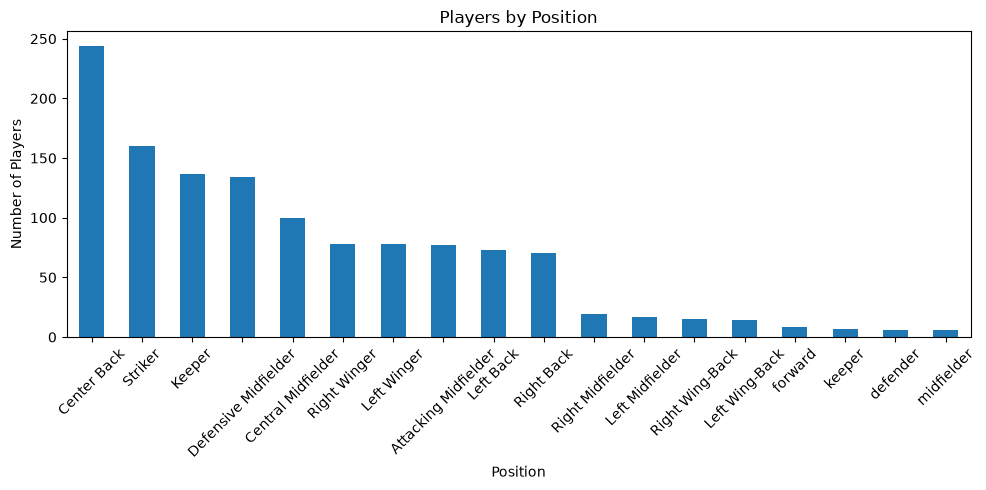

In [96]:

# POSITION DISTRIBUTION


position_counts = df["position"].value_counts()

print(position_counts)

position_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Players by Position")
plt.xlabel("Position")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [97]:

# PLAYER PERFORMANCE


performance = df[
    ["player_name", "goals", "assists", "rating"]
].copy()

print("Top players by goals:")
display(
    performance
    .sort_values("goals", ascending=False)
    .head(10)
)

print("Top players by assists:")
display(
    performance
    .sort_values("assists", ascending=False)
    .head(10)
)

print("Top players by rating:")
display(
    performance
    .sort_values("rating", ascending=False)
    .head(10)
)

Top players by goals:


,player_name,goals,assists,rating
1070,Harry Kane,73.0,8.0,7.622857
845,Kylian Mbappé,60.0,14.0,7.914286
1106,Erling Haaland,59.0,11.0,7.342647
502,Lionel Messi,48.0,34.0,8.223636
1002,Luis Suárez,43.0,9.0,6.825000
1073,Ivan Toney,42.0,11.0,6.254839
1043,Cristiano Ronaldo,42.0,4.0,7.523077
610,Julián Quiñones,41.0,5.0,7.466667
724,Ayase Ueda,32.0,3.0,6.772222
821,Mikel Oyarzabal,32.0,9.0,6.849180


Top players by assists:


,player_name,goals,assists,rating
502,Lionel Messi,48.0,34.0,8.223636
828,Michael Olise,25.0,34.0,7.778571
1047,Bruno Fernandes,16.0,26.0,7.452727
1007,Luis Díaz,30.0,25.0,7.690000
1104,Julian Ryerson,0.0,23.0,6.520635
1055,Joao Félix,29.0,21.0,7.501587
808,Lamine Yamal,29.0,21.0,8.022951
470,Arda Güler,8.0,20.0,7.244615
276,Akram Afif,19.0,20.0,7.200000
918,Heung-Min Son,20.0,19.0,7.450980


Top players by rating:


,player_name,goals,assists,rating
502,Lionel Messi,48.0,34.0,8.223636
808,Lamine Yamal,29.0,21.0,8.022951
845,Kylian Mbappé,60.0,14.0,7.914286
828,Michael Olise,25.0,34.0,7.778571
1007,Luis Díaz,30.0,25.0,7.690000
1070,Harry Kane,73.0,8.0,7.622857
1043,Cristiano Ronaldo,42.0,4.0,7.523077
1055,Joao Félix,29.0,21.0,7.501587
977,Vinícius Júnior,28.0,14.0,7.492647
610,Julián Quiñones,41.0,5.0,7.466667


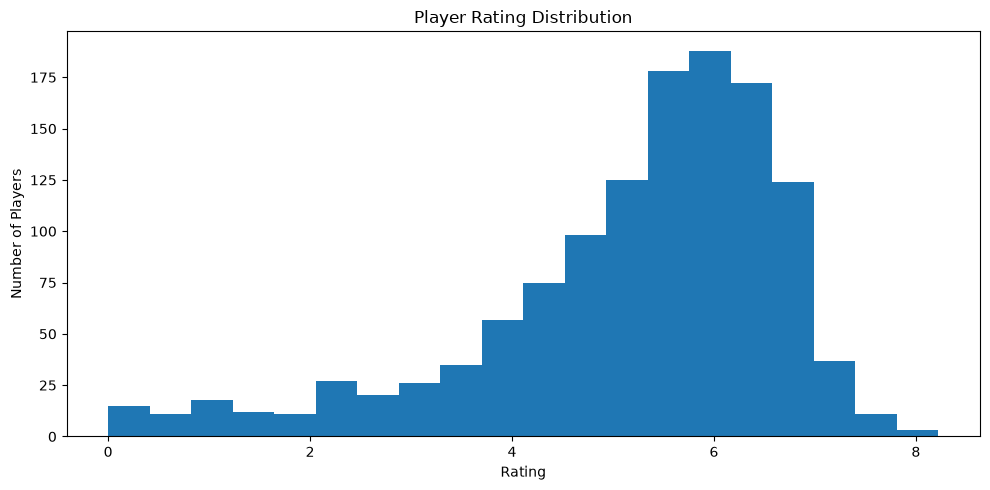

In [98]:

# RATING DISTRIBUTION


plt.figure(figsize=(10, 5))

plt.hist(
    df["rating"].dropna(),
    bins=20
)

plt.title("Player Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

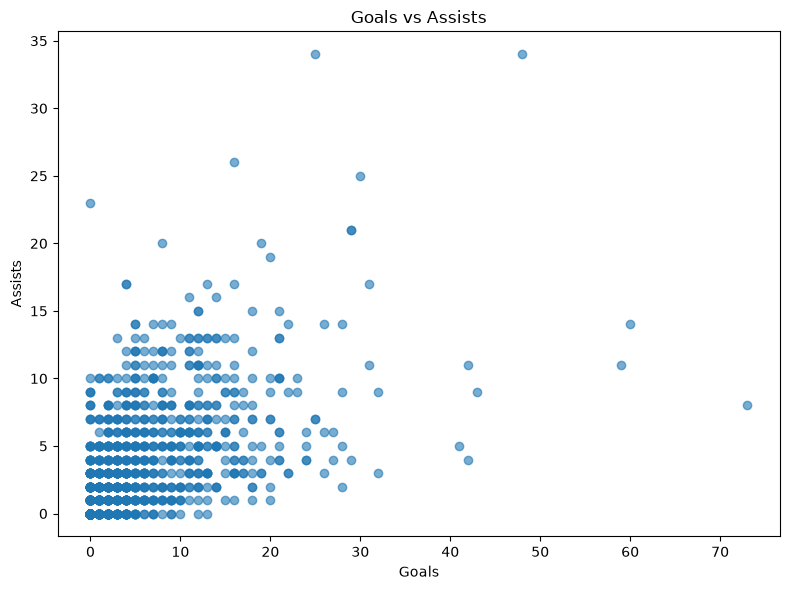

In [99]:

# GOALS VS ASSISTS


plt.figure(figsize=(8, 6))

plt.scatter(
    df["goals"],
    df["assists"],
    alpha=0.6
)

plt.title("Goals vs Assists")
plt.xlabel("Goals")
plt.ylabel("Assists")

plt.tight_layout()
plt.show()

In [100]:

#  FEATURE ENGINEERING


df["goal_assist_total"] = (
    df["goals"].fillna(0) +
    df["assists"].fillna(0)
)

df["goal_assist_ratio"] = (
    df["goals"] /
    df["assists"].replace(0, np.nan)
)

df["performance_score"] = (
    df["rating"].fillna(0) * 0.5 +
    df["goals"].fillna(0) * 0.3 +
    df["assists"].fillna(0) * 0.2
)

print(
    df[
        [
            "player_name",
            "goals",
            "assists",
            "rating",
            "goal_assist_total",
            "goal_assist_ratio",
            "performance_score"
        ]
    ].head()
)

         player_name  goals  assists    rating  goal_assist_total  \
0      Armin Gigovic    5.0      6.0  5.347368               11.0   
1         Jovo Lukic   18.0      2.0  5.640000               20.0   
2         Ivan Basic    2.0      2.0  3.875000                4.0   
3  Tarik Muharemovic    2.0      2.0  6.032653                4.0   
4       Samed Bazdar    5.0      2.0  2.922449                7.0   

   goal_assist_ratio  performance_score  
0           0.833333           5.373684  
1           9.000000           8.620000  
2           1.000000           2.937500  
3           1.000000           4.016327  
4           2.500000           3.361224  


In [101]:

#  TOP PERFORMERS


top_players = (
    df[
        [
            "player_id",
            "player_name",
            "position",
            "team_name",
            "goals",
            "assists",
            "rating",
            "goal_assist_total",
            "performance_score",
        ]
    ]
    .sort_values(
        ["performance_score", "rating", "goal_assist_total"],
        ascending=False
    )
    .head(20)
)

display(top_players)

,player_id,player_name,position,team_name,goals,assists,rating,goal_assist_total,performance_score
1070,194165,Harry Kane,Striker,Bayern München,73.0,8.0,7.622857,81.0,27.311429
502,30981,Lionel Messi,Striker,Inter Miami CF,48.0,34.0,8.223636,82.0,25.311818
845,701154,Kylian Mbappé,Striker,Real Madrid,60.0,14.0,7.914286,74.0,24.757143
1106,737066,Erling Haaland,Striker,Manchester City,59.0,11.0,7.342647,70.0,23.571324
828,1029063,Michael Olise,Right Winger,Bayern München,25.0,34.0,7.778571,59.0,18.189286
1002,792303,Luis Suárez,Striker,Sporting CP,43.0,9.0,6.825000,52.0,18.112500
1073,408987,Ivan Toney,Striker,Al Ahli,42.0,11.0,6.254839,53.0,17.927419
1007,860914,Luis Díaz,Left Winger,Bayern München,30.0,25.0,7.690000,55.0,17.845000
1043,30893,Cristiano Ronaldo,Striker,Al Nassr FC,42.0,4.0,7.523077,46.0,17.161538
610,720560,Julián Quiñones,Striker,Al Qadsiah,41.0,5.0,7.466667,46.0,17.033333


In [102]:

# FEATURE CORRELATION


correlation_cols = [
    "goals",
    "assists",
    "rating",
    "goal_assist_total",
    "performance_score",
]

correlation_matrix = df[correlation_cols].corr()

display(correlation_matrix)

,goals,assists,rating,goal_assist_total,performance_score
goals,1.000000,0.547422,0.370260,0.939514,0.929090
assists,0.547422,1.000000,0.473152,0.800942,0.760460
rating,0.370260,0.473152,1.000000,0.458560,0.628499
goal_assist_total,0.939514,0.800942,0.458560,1.000000,0.975973
performance_score,0.929090,0.760460,0.628499,0.975973,1.000000


In [103]:

#  POSITION ANALYSIS


position_performance = (
    df.groupby("position", dropna=False)
    .agg(
        players=("player_id", "count"),
        avg_rating=("rating", "mean"),
        total_goals=("goals", "sum"),
        total_assists=("assists", "sum"),
        avg_goal_assist=("goal_assist_total", "mean"),
    )
    .sort_values("avg_rating", ascending=False)
)

display(position_performance)

,players,avg_rating,total_goals,total_assists,avg_goal_assist
position,,,,,
Attacking Midfielder,77,5.932462,746.0,519.0,16.428571
Left Winger,78,5.849641,767.0,577.0,17.230769
Right Wing-Back,15,5.619714,42.0,78.0,8.000000
Defensive Midfielder,134,5.594159,473.0,479.0,7.104478
Central Midfielder,100,5.455492,381.0,358.0,7.390000
Right Midfielder,19,5.409652,77.0,79.0,8.210526
Striker,160,5.334005,2411.0,719.0,19.562500
Right Back,70,5.302257,139.0,298.0,6.242857
Right Winger,78,5.268782,626.0,464.0,13.974359


In [104]:
# SAVE ENGINEERED DATASET


df.to_csv(
    "data/processed/players_engineered.csv",
    index=False
)

print("Saved:")
print("data/processed/players_engineered.csv")
print("Shape:", df.shape)

Saved:
data/processed/players_engineered.csv
Shape: (1243, 25)


In [105]:

#  PREPARE MODELING DATASET


model_df = df.copy()

# Select reliable numeric features
feature_columns = [
    "goals",
    "assists",
    "rating",
    "goal_assist_total",
    "height",
    "weight",
]

# Keep only columns that actually exist
feature_columns = [
    col for col in feature_columns
    if col in model_df.columns
]

X = model_df[feature_columns].copy()

# Convert numeric columns safely
X = X.apply(pd.to_numeric, errors="coerce")

# Fill missing numeric values with median
X = X.fillna(X.median())

print("Features:")
print(feature_columns)

print("\nX shape:", X.shape)
print("\nMissing values:")
print(X.isna().sum())

Features:
['goals', 'assists', 'rating', 'goal_assist_total', 'height', 'weight']

X shape: (1243, 6)

Missing values:
goals                0
assists              0
rating               0
goal_assist_total    0
height               0
weight               0
dtype: int64


In [107]:

#  FEATURE SCALING

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=feature_columns,
    index=model_df.index
)

print("Scaled dataset shape:", X_scaled.shape)
display(X_scaled.head())

Scaled dataset shape: (1243, 6)


,goals,assists,rating,goal_assist_total,height,weight
0,-0.026796,0.629513,0.101150,0.238476,0.646258,0.331244
1,1.800226,-0.353199,0.293578,1.143439,1.089661,1.673862
2,-0.448417,-0.353199,-0.867048,-0.465384,-0.683951,-0.713015
3,-0.448417,-0.353199,0.551778,-0.465384,0.646258,0.480424
4,-0.026796,-0.353199,-1.493424,-0.163730,0.498457,0.032884


In [109]:

#  PLAYER PROFILE CLUSTERING


from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

model_df["player_cluster"] = kmeans.fit_predict(X_scaled)

print("Players per cluster:")
print(model_df["player_cluster"].value_counts().sort_index())

Players per cluster:
player_cluster
0    188
1    231
2    387
3    437
Name: count, dtype: int64


In [110]:

# CLUSTER ANALYSIS


cluster_summary = (
    model_df
    .groupby("player_cluster")[feature_columns]
    .mean()
    .round(2)
)

display(cluster_summary)

,goals,assists,rating,goal_assist_total,height,weight
player_cluster,,,,,,
0,16.98,9.65,6.46,26.64,180.93,74.2
1,1.32,0.58,2.74,1.90,184.29,77.59
2,3.93,3.82,5.59,7.75,176.51,70.02
3,3.28,1.93,5.59,5.21,187.92,80.68


In [111]:

#  TOP PLAYERS BY CLUSTER


for cluster in sorted(model_df["player_cluster"].unique()):

    print(f"\nCLUSTER {cluster} ")

    cluster_players = (
        model_df[
            model_df["player_cluster"] == cluster
        ]
        .sort_values("performance_score", ascending=False)
        [[
            "player_id",
            "player_name",
            "position",
            "team_name",
            "goals",
            "assists",
            "rating",
            "performance_score",
        ]]
        .head(10)
    )

    display(cluster_players)


CLUSTER 0 


,player_id,player_name,position,team_name,goals,assists,rating,performance_score
1070,194165,Harry Kane,Striker,Bayern München,73.0,8.0,7.622857,27.311429
502,30981,Lionel Messi,Striker,Inter Miami CF,48.0,34.0,8.223636,25.311818
845,701154,Kylian Mbappé,Striker,Real Madrid,60.0,14.0,7.914286,24.757143
1106,737066,Erling Haaland,Striker,Manchester City,59.0,11.0,7.342647,23.571324
828,1029063,Michael Olise,Right Winger,Bayern München,25.0,34.0,7.778571,18.189286
1002,792303,Luis Suárez,Striker,Sporting CP,43.0,9.0,6.825000,18.112500
1073,408987,Ivan Toney,Striker,Al Ahli,42.0,11.0,6.254839,17.927419
1007,860914,Luis Díaz,Left Winger,Bayern München,30.0,25.0,7.690000,17.845000
1043,30893,Cristiano Ronaldo,Striker,Al Nassr FC,42.0,4.0,7.523077,17.161538
610,720560,Julián Quiñones,Striker,Al Qadsiah,41.0,5.0,7.466667,17.033333



CLUSTER 1 


,player_id,player_name,position,team_name,goals,assists,rating,performance_score
396,1210929,Nadir Benbouali,Striker,Györi ETO,19.0,5.0,1.548889,7.474444
797,845336,Firas Chaouat,Striker,Club Africain,18.0,1.0,2.063636,6.631818
622,1031319,Amirhossein Hosseinzadeh,Striker,Tractor,14.0,2.0,2.207500,5.703750
317,1242314,Lenny Joseph,Striker,Ferencvaros,12.0,3.0,2.851786,5.625893
707,1611223,Kento Shiogai,Striker,Wolfsburg,10.0,1.0,4.023256,5.211628
903,909198,Abdullah Al-Hamdan,Striker,Al Nassr FC,10.0,2.0,3.141935,4.970968
1142,1558461,Findlay Curtis,Left Winger,Rangers,9.0,2.0,3.173770,4.686885
536,766159,Jordy Caicedo,Striker,Huracan,9.0,0.0,3.483333,4.441667
250,671326,Nuno da Costa,Striker,Başakşehir,6.0,3.0,3.822642,4.311321
255,873832,Willy Semedo,Left Winger,Omonia Nicosia,7.0,1.0,3.550000,4.075000



CLUSTER 2 


,player_id,player_name,position,team_name,goals,assists,rating,performance_score
880,1024928,Khalid Al Ghannam,Left Winger,Al-Ettifaq,13.0,6.0,5.988095,8.094048
373,1471333,Relebohile Mofokeng,Attacking Midfielder,Union St.Gilloise,11.0,8.0,6.152083,7.976042
210,1053736,Elijah Just,Attacking Midfielder,Motherwell,11.0,7.0,6.506000,7.953000
42,557677,Nikola Vlasic,Attacking Midfielder,Torino,12.0,5.0,6.509259,7.854630
983,1023030,Jhon Arias,Left Winger,Palmeiras,13.0,3.0,6.555224,7.777612
342,1287871,Zakaria El Ouahdi,Right Back,Genk,12.0,5.0,6.330909,7.765455
709,604044,Junya Ito,Left Winger,Genk,9.0,8.0,6.848980,7.724490
1035,1061249,Vitinha,Central Midfielder,Paris Saint-Germain,7.0,10.0,7.111765,7.655882
803,1083323,Pedri,Defensive Midfielder,Barcelona,5.0,12.0,7.369841,7.584921
602,1670377,Gilberto Mora,Central Midfielder,Tijuana,12.0,3.0,6.623684,7.511842



CLUSTER 3 


,player_id,player_name,position,team_name,goals,assists,rating,performance_score
1163,843099,Scott McTominay,Defensive Midfielder,Napoli,17.0,4.0,7.032759,9.416379
14,388903,Haris Tabakovic,Striker,Salzburg,19.0,3.0,6.130435,9.365217
666,848268,Haji Wright,Striker,Coventry City,20.0,2.0,5.580357,9.190179
137,1252132,Promise David,Striker,Union St.Gilloise,17.0,3.0,5.994000,8.697000
1195,1106563,Nick Woltemade,Striker,Newcastle United,16.0,5.0,5.767143,8.683571
1,1174844,Jovo Lukic,Striker,Universitatea Cluj,18.0,2.0,5.640000,8.620000
30,1210893,Igor Matanovic,Striker,Freiburg,16.0,4.0,5.822951,8.511475
529,1421270,Kevin Rodríguez,Striker,Union St.Gilloise,14.0,5.0,6.125926,8.262963
868,425711,Gabriel Ávalos,Striker,Independiente,13.0,7.0,5.706522,8.153261
772,726956,Cedric Itten,Striker,Werder Bremen,16.0,3.0,5.428889,8.114444


In [112]:
# Cluster distribution
cluster_counts = players_clustered["cluster"].value_counts().sort_index()

print("Players in each cluster:")
print(cluster_counts)

NameError: name 'players_clustered' is not defined

In [114]:
# Check which dataframe variables are available
print([
    name for name in list(globals().keys())
    if not name.startswith("_")
    and hasattr(globals().get(name), "columns")
])

['players_detailed', 'players_clean', 'record', 'players_detailed_clean', 'normalized', 'missing_report', 'recent_stats', 'messi', 'players_final', 'df', 'performance', 'top_players', 'correlation_matrix', 'position_performance', 'model_df', 'X', 'X_scaled', 'cluster_summary', 'cluster_players']


In [115]:

# FINAL CLUSTER ANALYSIS


# Use the existing clustered dataframe
players_clustered = cluster_players.copy()

print("Shape:", players_clustered.shape)
print("\nCluster distribution:")
print(players_clustered["cluster"].value_counts().sort_index())

print("\nCluster profile:")
cluster_profile = (
    players_clustered
    .groupby("cluster")
    [["goals", "assists", "rating",
      "goal_assist_total", "performance_score"]]
    .mean()
    .round(2)
)

display(cluster_profile)

Shape: (10, 8)

Cluster distribution:


KeyError: 'cluster'

In [116]:

# RECREATing CLUSTER LABELS
# Using the existing X_scaled


from sklearn.cluster import KMeans

# Create the same 4-cluster model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

print("Total cluster labels:", len(cluster_labels))
print("Cluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Total cluster labels: 1243
Cluster distribution:
0    188
1    231
2    387
3    437
Name: count, dtype: int64


In [117]:

# ADD CLUSTER LABELS TO FULL DATASET


model_clustered = model_df.copy()

model_clustered["cluster"] = cluster_labels

print("Final shape:", model_clustered.shape)
print("\nCluster distribution:")
print(model_clustered["cluster"].value_counts().sort_index())

Final shape: (1243, 27)

Cluster distribution:
cluster
0    188
1    231
2    387
3    437
Name: count, dtype: int64


In [118]:

cluster_profile = (
    model_clustered
    .groupby("cluster")
    [["goals", "assists", "rating",
      "goal_assist_total", "performance_score"]]
    .mean()
    .round(2)
)

display(cluster_profile)

,goals,assists,rating,goal_assist_total,performance_score
cluster,,,,,
0,16.98,9.65,6.46,26.64,10.26
1,1.32,0.58,2.74,1.90,1.88
2,3.93,3.82,5.59,7.75,4.74
3,3.28,1.93,5.59,5.21,4.17


In [119]:

# FINAL CLUSTER NAMES 
cluster_names = {
    0: "Elite / Top Performers",
    1: "Low-Performance Players",
    2: "Creative / Attacking Players",
    3: "Goal-Oriented Players"
}

model_clustered["cluster_name"] = (
    model_clustered["cluster"].map(cluster_names)
)

print("Cluster names assigned successfully.")

display(
    model_clustered[
        ["player_name", "goals", "assists", "rating",
         "performance_score", "cluster", "cluster_name"]
    ].head(10)
)

Cluster names assigned successfully.


,player_name,goals,assists,rating,performance_score,cluster,cluster_name
0,Armin Gigovic,5.0,6.0,5.347368,5.373684,3,Goal-Oriented Players
1,Jovo Lukic,18.0,2.0,5.640000,8.620000,3,Goal-Oriented Players
2,Ivan Basic,2.0,2.0,3.875000,2.937500,2,Creative / Attacking Players
3,Tarik Muharemovic,2.0,2.0,6.032653,4.016327,3,Goal-Oriented Players
4,Samed Bazdar,5.0,2.0,2.922449,3.361224,1,Low-Performance Players
5,Amar Memic,4.0,12.0,6.491228,6.845614,2,Creative / Attacking Players
6,Esmir Bajraktarevic,8.0,5.0,5.159677,5.979839,2,Creative / Attacking Players
7,Benjamin Tahirovic,3.0,2.0,5.868750,4.234375,3,Goal-Oriented Players
8,Arjan Malic,1.0,0.0,4.216667,2.408333,1,Low-Performance Players
9,Ermin Mahmic,10.0,3.0,4.575000,5.887500,3,Goal-Oriented Players


In [120]:

# FINAL CLUSTER DISTRIBUTION


cluster_distribution = (
    model_clustered
    .groupby(["cluster", "cluster_name"])
    .size()
    .reset_index(name="player_count")
)

display(cluster_distribution)

,cluster,cluster_name,player_count
0,0,Elite / Top Performers,188
1,1,Low-Performance Players,231
2,2,Creative / Attacking Players,387
3,3,Goal-Oriented Players,437


In [121]:

# TOP 10 PLAYERS PER CLUSTER


for cluster in sorted(model_clustered["cluster"].unique()):

    cluster_name = cluster_names[cluster]

    print(f"\n{'=' * 70}")
    print(f"CLUSTER {cluster}: {cluster_name}")
    print(f"{'=' * 70}")

    top = (
        model_clustered[
            model_clustered["cluster"] == cluster
        ]
        .sort_values("performance_score", ascending=False)
        [[
            "player_name",
            "position",
            "team_name",
            "goals",
            "assists",
            "rating",
            "performance_score"
        ]]
        .head(10)
    )

    display(top)


CLUSTER 0: Elite / Top Performers


,player_name,position,team_name,goals,assists,rating,performance_score
1070,Harry Kane,Striker,Bayern München,73.0,8.0,7.622857,27.311429
502,Lionel Messi,Striker,Inter Miami CF,48.0,34.0,8.223636,25.311818
845,Kylian Mbappé,Striker,Real Madrid,60.0,14.0,7.914286,24.757143
1106,Erling Haaland,Striker,Manchester City,59.0,11.0,7.342647,23.571324
828,Michael Olise,Right Winger,Bayern München,25.0,34.0,7.778571,18.189286
1002,Luis Suárez,Striker,Sporting CP,43.0,9.0,6.825000,18.112500
1073,Ivan Toney,Striker,Al Ahli,42.0,11.0,6.254839,17.927419
1007,Luis Díaz,Left Winger,Bayern München,30.0,25.0,7.690000,17.845000
1043,Cristiano Ronaldo,Striker,Al Nassr FC,42.0,4.0,7.523077,17.161538
610,Julián Quiñones,Striker,Al Qadsiah,41.0,5.0,7.466667,17.033333



CLUSTER 1: Low-Performance Players


,player_name,position,team_name,goals,assists,rating,performance_score
396,Nadir Benbouali,Striker,Györi ETO,19.0,5.0,1.548889,7.474444
797,Firas Chaouat,Striker,Club Africain,18.0,1.0,2.063636,6.631818
622,Amirhossein Hosseinzadeh,Striker,Tractor,14.0,2.0,2.207500,5.703750
317,Lenny Joseph,Striker,Ferencvaros,12.0,3.0,2.851786,5.625893
707,Kento Shiogai,Striker,Wolfsburg,10.0,1.0,4.023256,5.211628
903,Abdullah Al-Hamdan,Striker,Al Nassr FC,10.0,2.0,3.141935,4.970968
1142,Findlay Curtis,Left Winger,Rangers,9.0,2.0,3.173770,4.686885
536,Jordy Caicedo,Striker,Huracan,9.0,0.0,3.483333,4.441667
250,Nuno da Costa,Striker,Başakşehir,6.0,3.0,3.822642,4.311321
255,Willy Semedo,Left Winger,Omonia Nicosia,7.0,1.0,3.550000,4.075000



CLUSTER 2: Creative / Attacking Players


,player_name,position,team_name,goals,assists,rating,performance_score
880,Khalid Al Ghannam,Left Winger,Al-Ettifaq,13.0,6.0,5.988095,8.094048
373,Relebohile Mofokeng,Attacking Midfielder,Union St.Gilloise,11.0,8.0,6.152083,7.976042
210,Elijah Just,Attacking Midfielder,Motherwell,11.0,7.0,6.506000,7.953000
42,Nikola Vlasic,Attacking Midfielder,Torino,12.0,5.0,6.509259,7.854630
983,Jhon Arias,Left Winger,Palmeiras,13.0,3.0,6.555224,7.777612
342,Zakaria El Ouahdi,Right Back,Genk,12.0,5.0,6.330909,7.765455
709,Junya Ito,Left Winger,Genk,9.0,8.0,6.848980,7.724490
1035,Vitinha,Central Midfielder,Paris Saint-Germain,7.0,10.0,7.111765,7.655882
803,Pedri,Defensive Midfielder,Barcelona,5.0,12.0,7.369841,7.584921
602,Gilberto Mora,Central Midfielder,Tijuana,12.0,3.0,6.623684,7.511842



CLUSTER 3: Goal-Oriented Players


,player_name,position,team_name,goals,assists,rating,performance_score
1163,Scott McTominay,Defensive Midfielder,Napoli,17.0,4.0,7.032759,9.416379
14,Haris Tabakovic,Striker,Salzburg,19.0,3.0,6.130435,9.365217
666,Haji Wright,Striker,Coventry City,20.0,2.0,5.580357,9.190179
137,Promise David,Striker,Union St.Gilloise,17.0,3.0,5.994000,8.697000
1195,Nick Woltemade,Striker,Newcastle United,16.0,5.0,5.767143,8.683571
1,Jovo Lukic,Striker,Universitatea Cluj,18.0,2.0,5.640000,8.620000
30,Igor Matanovic,Striker,Freiburg,16.0,4.0,5.822951,8.511475
529,Kevin Rodríguez,Striker,Union St.Gilloise,14.0,5.0,6.125926,8.262963
868,Gabriel Ávalos,Striker,Independiente,13.0,7.0,5.706522,8.153261
772,Cedric Itten,Striker,Werder Bremen,16.0,3.0,5.428889,8.114444


In [123]:

# SAVE FINAL CLUSTERED DATASET

import os

os.makedirs("data/processed", exist_ok=True)

final_path = "data/processed/worldcup_player_clusters.csv"

model_clustered.to_csv(final_path, index=False)

print(f"Final dataset saved to: {final_path}")
print("Final shape:", model_clustered.shape)

Final dataset saved to: data/processed/worldcup_player_clusters.csv
Final shape: (1243, 28)


In [ ]:
Players were segmented using K-Means clustering into four performance-based groups: Elite/Top Performers, Low-Performance Players, Creative/Attacking Players, and Goal-Oriented Players.

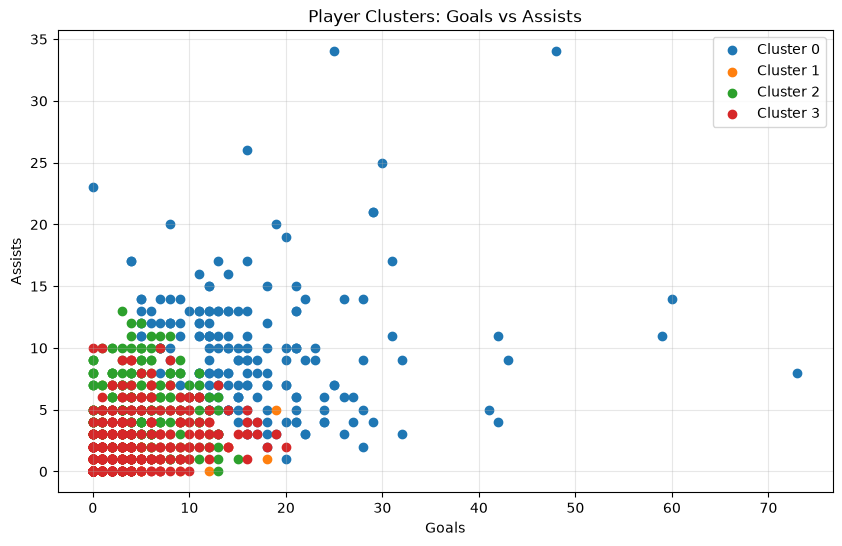

In [124]:

# CLUSTER VISUALIZATION


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for cluster in sorted(model_clustered["cluster"].unique()):
    data = model_clustered[model_clustered["cluster"] == cluster]

    plt.scatter(
        data["goals"],
        data["assists"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Goals")
plt.ylabel("Assists")
plt.title("Player Clusters: Goals vs Assists")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [125]:

# CLUSTER PERFORMANCE COMPARISON


cluster_profile = (
    model_clustered
    .groupby(["cluster", "cluster_name"])[
        ["goals", "assists", "rating", "performance_score"]
    ]
    .mean()
    .round(2)
)

display(cluster_profile)

,,goals,assists,rating,performance_score
cluster,cluster_name,,,,
0,Elite / Top Performers,16.98,9.65,6.46,10.26
1,Low-Performance Players,1.32,0.58,2.74,1.88
2,Creative / Attacking Players,3.93,3.82,5.59,4.74
3,Goal-Oriented Players,3.28,1.93,5.59,4.17


In [126]:

# FINAL PLAYER INSIGHTS


for cluster in sorted(model_clustered["cluster"].unique()):

    name = cluster_names[cluster]

    print(f"\n{'=' * 60}")
    print(f"CLUSTER {cluster} — {name}")
    print(f"{'=' * 60}")

    top_players = (
        model_clustered[
            model_clustered["cluster"] == cluster
        ]
        .sort_values("performance_score", ascending=False)
        [[
            "player_name",
            "position",
            "team_name",
            "goals",
            "assists",
            "rating",
            "performance_score"
        ]]
        .head(5)
    )

    display(top_players)


CLUSTER 0 — Elite / Top Performers


,player_name,position,team_name,goals,assists,rating,performance_score
1070,Harry Kane,Striker,Bayern München,73.0,8.0,7.622857,27.311429
502,Lionel Messi,Striker,Inter Miami CF,48.0,34.0,8.223636,25.311818
845,Kylian Mbappé,Striker,Real Madrid,60.0,14.0,7.914286,24.757143
1106,Erling Haaland,Striker,Manchester City,59.0,11.0,7.342647,23.571324
828,Michael Olise,Right Winger,Bayern München,25.0,34.0,7.778571,18.189286



CLUSTER 1 — Low-Performance Players


,player_name,position,team_name,goals,assists,rating,performance_score
396,Nadir Benbouali,Striker,Györi ETO,19.0,5.0,1.548889,7.474444
797,Firas Chaouat,Striker,Club Africain,18.0,1.0,2.063636,6.631818
622,Amirhossein Hosseinzadeh,Striker,Tractor,14.0,2.0,2.207500,5.703750
317,Lenny Joseph,Striker,Ferencvaros,12.0,3.0,2.851786,5.625893
707,Kento Shiogai,Striker,Wolfsburg,10.0,1.0,4.023256,5.211628



CLUSTER 2 — Creative / Attacking Players


,player_name,position,team_name,goals,assists,rating,performance_score
880,Khalid Al Ghannam,Left Winger,Al-Ettifaq,13.0,6.0,5.988095,8.094048
373,Relebohile Mofokeng,Attacking Midfielder,Union St.Gilloise,11.0,8.0,6.152083,7.976042
210,Elijah Just,Attacking Midfielder,Motherwell,11.0,7.0,6.506000,7.953000
42,Nikola Vlasic,Attacking Midfielder,Torino,12.0,5.0,6.509259,7.854630
983,Jhon Arias,Left Winger,Palmeiras,13.0,3.0,6.555224,7.777612



CLUSTER 3 — Goal-Oriented Players


,player_name,position,team_name,goals,assists,rating,performance_score
1163,Scott McTominay,Defensive Midfielder,Napoli,17.0,4.0,7.032759,9.416379
14,Haris Tabakovic,Striker,Salzburg,19.0,3.0,6.130435,9.365217
666,Haji Wright,Striker,Coventry City,20.0,2.0,5.580357,9.190179
137,Promise David,Striker,Union St.Gilloise,17.0,3.0,5.994000,8.697000
1195,Nick Woltemade,Striker,Newcastle United,16.0,5.0,5.767143,8.683571


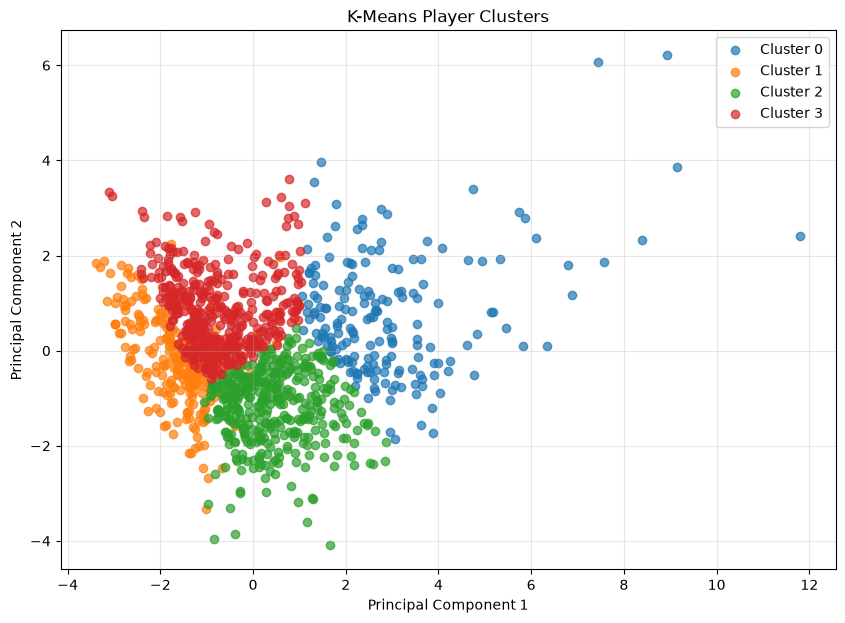

Explained variance: 76.87 %


In [127]:

# PCA VISUALIZATION OF PLAYER CLUSTERS


from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=model_clustered.index
)

pca_df["cluster"] = model_clustered["cluster"].values

plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df["cluster"].unique()):
    data = pca_df[pca_df["cluster"] == cluster]

    plt.scatter(
        data["PC1"],
        data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Player Clusters")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(
    "Explained variance:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

In [128]:

# SILHOUETTE SCORE

from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_scaled,
    model_clustered["cluster"]
)

print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.2442


In [129]:

# SAVING FINAL CLUSTERED DATA


import os

os.makedirs("data/processed", exist_ok=True)

final_path = "data/processed/worldcup_player_clusters.csv"

model_clustered.to_csv(final_path, index=False)

print("Saved:", final_path)
print("Final shape:", model_clustered.shape)
print("Columns:", model_clustered.columns.tolist())

Saved: data/processed/worldcup_player_clusters.csv
Final shape: (1243, 28)
Columns: ['player_id', 'player_name', 'is_captain', 'gender', 'birth_date', 'team_id', 'team_name', 'on_loan', 'position', 'position_key', 'height', 'height_unit', 'weight', 'weight_unit', 'nationality', 'rating', 'goals', 'assists', 'market_value', 'contract_end', 'injury', 'injury_expected_return', 'goal_assist_total', 'goal_assist_ratio', 'performance_score', 'player_cluster', 'cluster', 'cluster_name']


In [ ]:
Raw player JSON → Cleaning → Feature extraction → Feature engineering → Scaling → K-Means → 4 player clusters → PCA visualization → Cluster evaluation → Final dataset

In [130]:

# FINAL CLUSTER VALIDATION


import pandas as pd

# Load the final clustered dataset
clustered_players = pd.read_csv(
    "data/processed/worldcup_player_clusters.csv"
)

print("Dataset shape:", clustered_players.shape)

print("\nCluster distribution:")
print(
    clustered_players["cluster_name"]
    .value_counts()
    .sort_index()
)

print("\nCluster summary:")
print(
    clustered_players.groupby(
        ["cluster", "cluster_name"]
    )[[
        "goals",
        "assists",
        "rating",
        "goal_assist_total",
        "performance_score"
    ]]
    .mean()
    .round(2)
)

print("\nMissing values:")
print(
    clustered_players.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

print("\nFinal dataset preview:")
display(
    clustered_players.head()
)

Dataset shape: (1243, 28)

Cluster distribution:
cluster_name
Creative / Attacking Players    387
Elite / Top Performers          188
Goal-Oriented Players           437
Low-Performance Players         231
Name: count, dtype: int64

Cluster summary:
                                      goals  assists  rating  \
cluster cluster_name                                           
0       Elite / Top Performers        16.98     9.65    6.46   
1       Low-Performance Players        1.32     0.58    2.74   
2       Creative / Attacking Players   3.93     3.82    5.59   
3       Goal-Oriented Players          3.28     1.93    5.59   

                                      goal_assist_total  performance_score  
cluster cluster_name                                                        
0       Elite / Top Performers                    26.64              10.26  
1       Low-Performance Players                    1.90               1.88  
2       Creative / Attacking Players               7.75  

,player_id,player_name,is_captain,gender,birth_date,team_id,team_name,on_loan,position,position_key,...,market_value,contract_end,injury,injury_expected_return,goal_assist_total,goal_assist_ratio,performance_score,player_cluster,cluster,cluster_name
0,1057426,Armin Gigovic,False,male,2002-04-06 00:00:00+00:00,10192.0,Young Boys,False,Defensive Midfielder,centerdefensivemidfielder,...,NaN,2029-06-30 00:00:00+00:00,NaN,NaN,11.0,0.833333,5.373684,3,3,Goal-Oriented Players
1,1174844,Jovo Lukic,False,male,1998-11-28 00:00:00+00:00,89022.0,Universitatea Cluj,False,Striker,striker,...,NaN,2029-06-30 00:00:00+00:00,NaN,NaN,20.0,9.000000,8.620000,3,3,Goal-Oriented Players
2,1179875,Ivan Basic,False,male,2002-04-30 00:00:00+00:00,166865.0,FC Astana,False,Central Midfielder,centermidfielder,...,NaN,2026-12-31 00:00:00+00:00,NaN,NaN,4.0,1.000000,2.937500,2,2,Creative / Attacking Players
3,1250485,Tarik Muharemovic,False,male,2003-02-28 00:00:00+00:00,8463.0,Leeds United,False,Center Back,centerback,...,17870981.0,2031-06-30 00:00:00+00:00,NaN,NaN,4.0,1.000000,4.016327,3,3,Goal-Oriented Players
4,1284492,Samed Bazdar,False,male,2004-01-31 00:00:00+00:00,8394.0,Real Zaragoza,False,Striker,striker,...,NaN,2029-06-30 00:00:00+00:00,NaN,NaN,7.0,2.500000,3.361224,1,1,Low-Performance Players


Explained variance:
PC1: 65.86%
PC2: 19.77%
PC1 + PC2: 85.63%


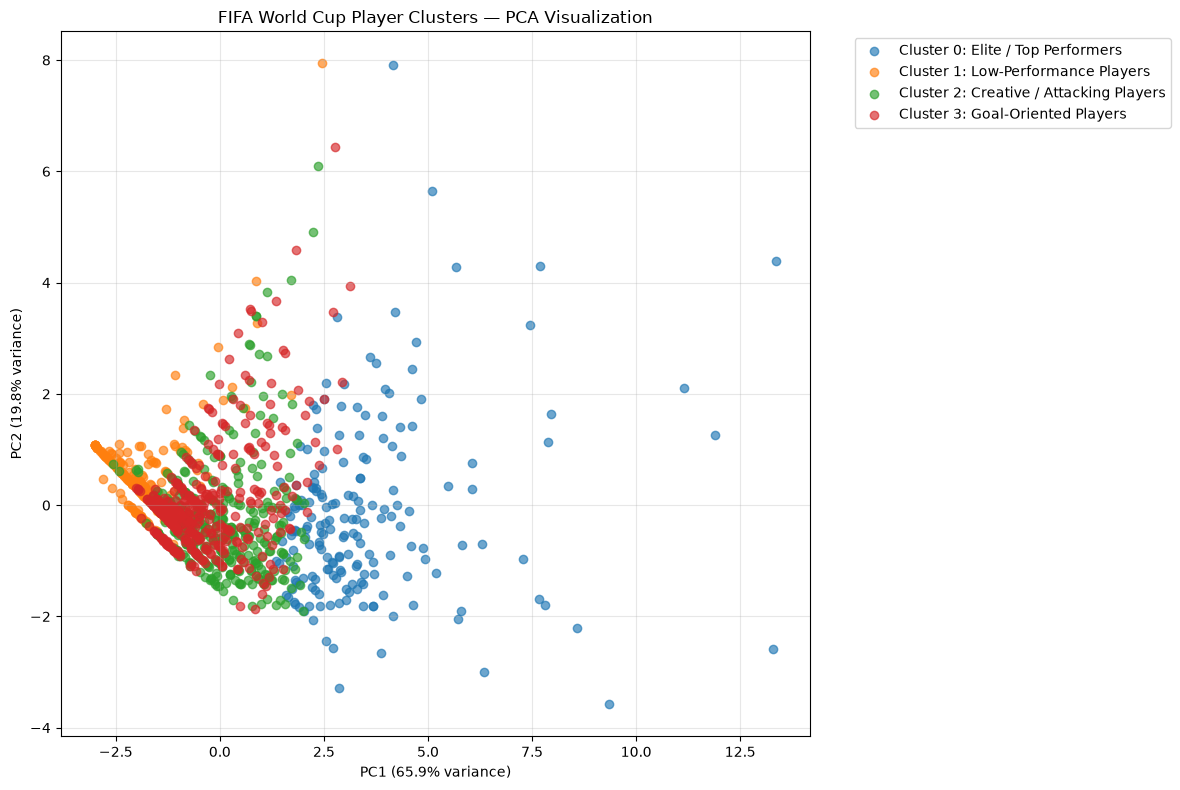

In [131]:

# PCA VISUALIZATION OF PLAYER CLUSTERS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load final clustered dataset
players_clustered = pd.read_csv(
    "data/processed/worldcup_player_clusters.csv"
)

# Features used for visualization
features = [
    "goals",
    "assists",
    "rating",
    "goal_assist_total",
    "goal_assist_ratio",
    "performance_score"
]

# Keep only required numeric columns
pca_data = players_clustered[features].copy()

# Handle missing/infinite values safely
pca_data = pca_data.replace([np.inf, -np.inf], np.nan)

# Median imputation
pca_data = pca_data.fillna(pca_data.median())

# Standardize manually
X = pca_data.to_numpy(dtype=float)

mean = X.mean(axis=0)
std = X.std(axis=0)

# Prevent division by zero
std[std == 0] = 1

X_scaled = (X - mean) / std


# PCA using NumPy


# Center data
X_centered = X_scaled - X_scaled.mean(axis=0)

# Singular Value Decomposition
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# First two principal components
X_pca = U[:, :2] * S[:2]

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Add cluster information
pca_df["cluster"] = players_clustered["cluster"].values
pca_df["cluster_name"] = players_clustered["cluster_name"].values


# Explained variance


explained_variance = (S ** 2) / np.sum(S ** 2)

print("Explained variance:")
print(f"PC1: {explained_variance[0] * 100:.2f}%")
print(f"PC2: {explained_variance[1] * 100:.2f}%")
print(
    f"PC1 + PC2: "
    f"{(explained_variance[0] + explained_variance[1]) * 100:.2f}%"
)


# Plot gareko


plt.figure(figsize=(12, 8))

for cluster_id in sorted(pca_df["cluster"].unique()):

    cluster_data = pca_df[
        pca_df["cluster"] == cluster_id
    ]

    cluster_name = cluster_data["cluster_name"].iloc[0]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster_id}: {cluster_name}",
        alpha=0.65
    )

plt.xlabel(
    f"PC1 ({explained_variance[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1] * 100:.1f}% variance)"
)

plt.title("FIFA World Cup Player Clusters — PCA Visualization")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [132]:

# TOP 10 PLAYERS FROM EACH CLUSTER


import pandas as pd

players_clustered = pd.read_csv(
    "data/processed/worldcup_player_clusters.csv"
)

top_players_by_cluster = (
    players_clustered
    .sort_values(
        ["cluster", "performance_score"],
        ascending=[True, False]
    )
    .groupby("cluster")
    .head(10)
    [[
        "player_id",
        "player_name",
        "position",
        "team_name",
        "goals",
        "assists",
        "rating",
        "goal_assist_total",
        "performance_score",
        "cluster",
        "cluster_name"
    ]]
    .reset_index(drop=True)
)

display(top_players_by_cluster)

,player_id,player_name,position,team_name,goals,assists,rating,goal_assist_total,performance_score,cluster,cluster_name
0,194165,Harry Kane,Striker,Bayern München,73.0,8.0,7.622857,81.0,27.311429,0,Elite / Top Performers
1,30981,Lionel Messi,Striker,Inter Miami CF,48.0,34.0,8.223636,82.0,25.311818,0,Elite / Top Performers
2,701154,Kylian Mbappé,Striker,Real Madrid,60.0,14.0,7.914286,74.0,24.757143,0,Elite / Top Performers
3,737066,Erling Haaland,Striker,Manchester City,59.0,11.0,7.342647,70.0,23.571324,0,Elite / Top Performers
4,1029063,Michael Olise,Right Winger,Bayern München,25.0,34.0,7.778571,59.0,18.189286,0,Elite / Top Performers
5,792303,Luis Suárez,Striker,Sporting CP,43.0,9.0,6.825000,52.0,18.112500,0,Elite / Top Performers
6,408987,Ivan Toney,Striker,Al Ahli,42.0,11.0,6.254839,53.0,17.927419,0,Elite / Top Performers
7,860914,Luis Díaz,Left Winger,Bayern München,30.0,25.0,7.690000,55.0,17.845000,0,Elite / Top Performers
8,30893,Cristiano Ronaldo,Striker,Al Nassr FC,42.0,4.0,7.523077,46.0,17.161538,0,Elite / Top Performers
9,720560,Julián Quiñones,Striker,Al Qadsiah,41.0,5.0,7.466667,46.0,17.033333,0,Elite / Top Performers


In [133]:
# Save top players from each cluster

top_players_by_cluster.to_csv(
    "data/processed/top_players_by_cluster.csv",
    index=False
)

print("Saved: data/processed/top_players_by_cluster.csv")
print("Shape:", top_players_by_cluster.shape)

Saved: data/processed/top_players_by_cluster.csv
Shape: (40, 11)


In [134]:
luster_distribution = (
    players_clustered
    .groupby(["cluster", "cluster_name"])
    .size()
    .reset_index(name="player_count")
)

display(cluster_distribution)

,cluster,cluster_name,player_count
0,0,Elite / Top Performers,188
1,1,Low-Performance Players,231
2,2,Creative / Attacking Players,387
3,3,Goal-Oriented Players,437


In [135]:

# FINAL PLAYER IMPACT RANKING


import pandas as pd
import numpy as np

players_clustered = pd.read_csv(
    "data/processed/worldcup_player_clusters.csv"
)

# Normalize performance score
score_min = players_clustered["performance_score"].min()
score_max = players_clustered["performance_score"].max()

players_clustered["impact_score"] = (
    (players_clustered["performance_score"] - score_min)
    / (score_max - score_min)
    * 100
).round(2)

# Rank all players
players_clustered["overall_rank"] = (
    players_clustered["impact_score"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# Final ranking
final_ranking = (
    players_clustered
    .sort_values("overall_rank")
    [[
        "overall_rank",
        "player_id",
        "player_name",
        "position",
        "team_name",
        "goals",
        "assists",
        "rating",
        "performance_score",
        "impact_score",
        "cluster",
        "cluster_name"
    ]]
    .reset_index(drop=True)
)

display(final_ranking.head(20))

,overall_rank,player_id,player_name,position,team_name,goals,assists,rating,performance_score,impact_score,cluster,cluster_name
0,1,194165,Harry Kane,Striker,Bayern München,73.0,8.0,7.622857,27.311429,100.00,0,Elite / Top Performers
1,2,30981,Lionel Messi,Striker,Inter Miami CF,48.0,34.0,8.223636,25.311818,92.68,0,Elite / Top Performers
2,3,701154,Kylian Mbappé,Striker,Real Madrid,60.0,14.0,7.914286,24.757143,90.65,0,Elite / Top Performers
3,4,737066,Erling Haaland,Striker,Manchester City,59.0,11.0,7.342647,23.571324,86.31,0,Elite / Top Performers
4,5,1029063,Michael Olise,Right Winger,Bayern München,25.0,34.0,7.778571,18.189286,66.60,0,Elite / Top Performers
5,6,792303,Luis Suárez,Striker,Sporting CP,43.0,9.0,6.825000,18.112500,66.32,0,Elite / Top Performers
6,7,408987,Ivan Toney,Striker,Al Ahli,42.0,11.0,6.254839,17.927419,65.64,0,Elite / Top Performers
7,8,860914,Luis Díaz,Left Winger,Bayern München,30.0,25.0,7.690000,17.845000,65.34,0,Elite / Top Performers
8,9,30893,Cristiano Ronaldo,Striker,Al Nassr FC,42.0,4.0,7.523077,17.161538,62.84,0,Elite / Top Performers
9,10,720560,Julián Quiñones,Striker,Al Qadsiah,41.0,5.0,7.466667,17.033333,62.37,0,Elite / Top Performers


In [136]:

# Save final player ranking

final_ranking.to_csv(
    "data/processed/final_player_ranking.csv",
    index=False
)

print("Saved: data/processed/final_player_ranking.csv")
print("Total ranked players:", len(final_ranking))

Saved: data/processed/final_player_ranking.csv
Total ranked players: 1243


In [137]:
top_20 = final_ranking.head(20)

display(top_20)

,overall_rank,player_id,player_name,position,team_name,goals,assists,rating,performance_score,impact_score,cluster,cluster_name
0,1,194165,Harry Kane,Striker,Bayern München,73.0,8.0,7.622857,27.311429,100.00,0,Elite / Top Performers
1,2,30981,Lionel Messi,Striker,Inter Miami CF,48.0,34.0,8.223636,25.311818,92.68,0,Elite / Top Performers
2,3,701154,Kylian Mbappé,Striker,Real Madrid,60.0,14.0,7.914286,24.757143,90.65,0,Elite / Top Performers
3,4,737066,Erling Haaland,Striker,Manchester City,59.0,11.0,7.342647,23.571324,86.31,0,Elite / Top Performers
4,5,1029063,Michael Olise,Right Winger,Bayern München,25.0,34.0,7.778571,18.189286,66.60,0,Elite / Top Performers
5,6,792303,Luis Suárez,Striker,Sporting CP,43.0,9.0,6.825000,18.112500,66.32,0,Elite / Top Performers
6,7,408987,Ivan Toney,Striker,Al Ahli,42.0,11.0,6.254839,17.927419,65.64,0,Elite / Top Performers
7,8,860914,Luis Díaz,Left Winger,Bayern München,30.0,25.0,7.690000,17.845000,65.34,0,Elite / Top Performers
8,9,30893,Cristiano Ronaldo,Striker,Al Nassr FC,42.0,4.0,7.523077,17.161538,62.84,0,Elite / Top Performers
9,10,720560,Julián Quiñones,Striker,Al Qadsiah,41.0,5.0,7.466667,17.033333,62.37,0,Elite / Top Performers


In [138]:
top_20_cluster_summary = (
    top_20
    .groupby(["cluster", "cluster_name"])
    .agg(
        players=("player_id", "count"),
        avg_goals=("goals", "mean"),
        avg_assists=("assists", "mean"),
        avg_rating=("rating", "mean"),
        avg_performance=("performance_score", "mean"),
        avg_impact=("impact_score", "mean")
    )
    .round(2)
    .reset_index()
)

display(top_20_cluster_summary)

,cluster,cluster_name,players,avg_goals,avg_assists,avg_rating,avg_performance,avg_impact
0,0,Elite / Top Performers,20,37.25,15.0,7.34,17.85,65.34


In [140]:

# BEST PLAYER FROM EACH CLUSTER


best_by_cluster = (
    final_ranking
    .sort_values("impact_score", ascending=False)
    .groupby("cluster")
    .head(1)
    [[
        "player_name",
        "position",
        "team_name",
        "goals",
        "assists",
        "rating",
        "performance_score",
        "impact_score",
        "cluster_name"
    ]]
    .sort_values("cluster")
    .reset_index(drop=True)
)

display(best_by_cluster)

KeyError: 'cluster'

In [141]:


import pandas as pd

# Load the saved final ranking directly
final_ranking = pd.read_csv(
    "data/processed/final_player_ranking.csv"
)

# Make sure cluster is a normal column
final_ranking = final_ranking.reset_index(drop=True)

print("Columns available:")
print(final_ranking.columns.tolist())

# Find the highest-impact player in each cluster
best_indices = (
    final_ranking
    .groupby("cluster")["impact_score"]
    .idxmax()
)

best_by_cluster = (
    final_ranking.loc[best_indices]
    [[
        "cluster",
        "cluster_name",
        "player_name",
        "position",
        "team_name",
        "goals",
        "assists",
        "rating",
        "performance_score",
        "impact_score"
    ]]
    .sort_values("cluster")
    .reset_index(drop=True)
)

print("\nBest player from each cluster:")
display(best_by_cluster)

Columns available:
['overall_rank', 'player_id', 'player_name', 'position', 'team_name', 'goals', 'assists', 'rating', 'performance_score', 'impact_score', 'cluster', 'cluster_name']

Best player from each cluster:


,cluster,cluster_name,player_name,position,team_name,goals,assists,rating,performance_score,impact_score
0,0,Elite / Top Performers,Harry Kane,Striker,Bayern München,73.0,8.0,7.622857,27.311429,100.00
1,1,Low-Performance Players,Nadir Benbouali,Striker,Györi ETO,19.0,5.0,1.548889,7.474444,27.37
2,2,Creative / Attacking Players,Khalid Al Ghannam,Left Winger,Al-Ettifaq,13.0,6.0,5.988095,8.094048,29.64
3,3,Goal-Oriented Players,Scott McTominay,Defensive Midfielder,Napoli,17.0,4.0,7.032759,9.416379,34.48


In [142]:
# Save best player from each cluster

best_by_cluster.to_csv(
    "data/processed/best_player_by_cluster.csv",
    index=False
)

print("Saved: data/processed/best_player_by_cluster.csv")

Saved: data/processed/best_player_by_cluster.csv


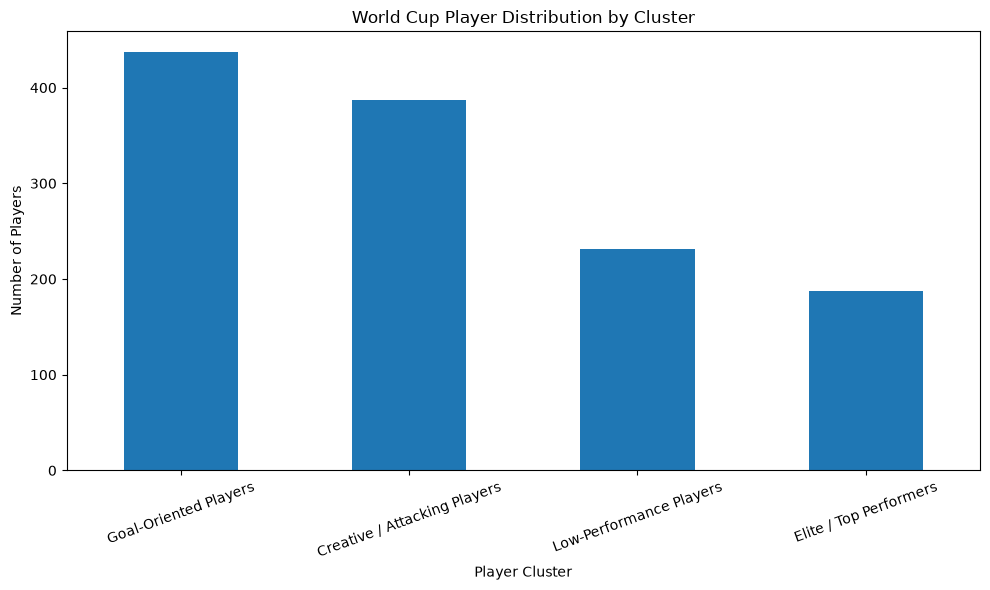

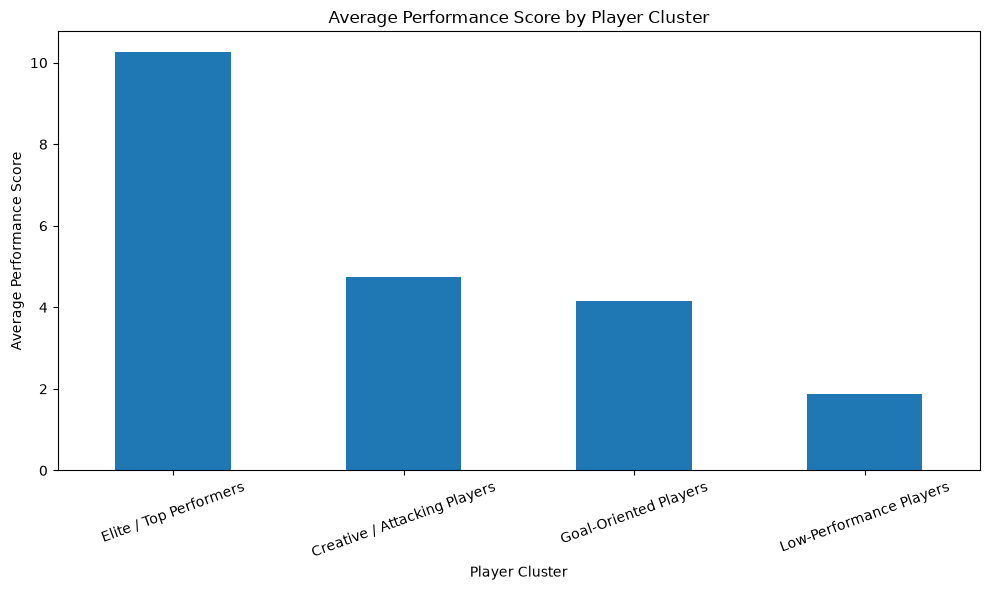

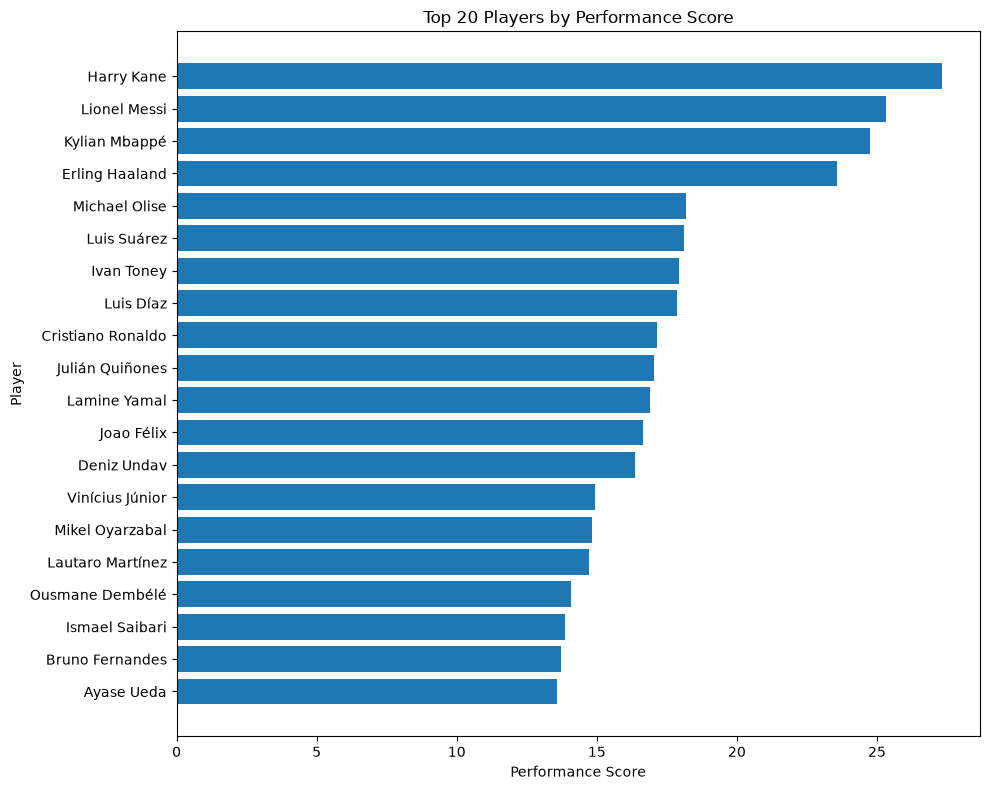

In [143]:

# FINAL VISUAL ANALYSIS


import pandas as pd
import matplotlib.pyplot as plt

# Load final dataset
players = pd.read_csv(
    "data/processed/worldcup_player_clusters.csv"
)


#  PLAYER DISTRIBUTION BY CLUSTER


cluster_counts = (
    players["cluster_name"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

cluster_counts.plot(kind="bar")

plt.title("World Cup Player Distribution by Cluster")
plt.xlabel("Player Cluster")
plt.ylabel("Number of Players")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()



#  AVERAGE PERFORMANCE BY CLUSTER


cluster_performance = (
    players
    .groupby("cluster_name")["performance_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

cluster_performance.plot(kind="bar")

plt.title("Average Performance Score by Player Cluster")
plt.xlabel("Player Cluster")
plt.ylabel("Average Performance Score")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()



# TOP 20 PLAYER PERFORMANCE


top_20 = (
    players
    .sort_values("performance_score", ascending=False)
    .head(20)
    .sort_values("performance_score")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_20["player_name"],
    top_20["performance_score"]
)

plt.title("Top 20 Players by Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Player")

plt.tight_layout()

plt.show()

In [145]:

# SAVING FINAL VISUALIZATIONS


import os

os.makedirs("reports/figures", exist_ok=True)

#  Cluster distribution
plt.figure(figsize=(10, 6))
cluster_counts.plot(kind="bar")
plt.title("World Cup Player Distribution by Cluster")
plt.xlabel("Player Cluster")
plt.ylabel("Number of Players")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(
    "reports/figures/cluster_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

#  Cluster performance
plt.figure(figsize=(10, 6))
cluster_performance.plot(kind="bar")
plt.title("Average Performance Score by Player Cluster")
plt.xlabel("Player Cluster")
plt.ylabel("Average Performance Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(
    "reports/figures/cluster_performance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

#  Top 20
plt.figure(figsize=(10, 8))
plt.barh(
    top_20["player_name"],
    top_20["performance_score"]
)
plt.title("Top 20 Players by Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Player")
plt.tight_layout()
plt.savefig(
    "reports/figures/top_20_players.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

print("All visualizations saved ")

All visualizations saved 


In [149]:
import os

files = [
    "data/processed/worldcup_player_clusters.csv",
    "data/processed/final_player_ranking.csv",
    "data/processed/best_player_by_cluster.csv",
    "reports/figures/cluster_distribution.png",
    "reports/figures/cluster_performance.png",
    "reports/figures/top_20_players.png"
]

for file in files:
    print(f"{'vayo' if os.path.exists(file) else 'vayena'} {file}")

vayo data/processed/worldcup_player_clusters.csv
vayo data/processed/final_player_ranking.csv
vayo data/processed/best_player_by_cluster.csv
vayo reports/figures/cluster_distribution.png
vayo reports/figures/cluster_performance.png
vayo reports/figures/top_20_players.png
